## MinFin

This notebook implements *MinFin*, an analytical model developed to identify energy sector financing gaps for climate transitions in low- and middle-income countries (LMICs). MinFin quantifies investment needs, estimates financing costs, and evaluates anticipated sectoral cashflows to highlight financial shortfalls and explore feasible strategies to bridge them. The model’s primary goal is to facilitate better collaboration between energy and finance ministries, ensuring that energy planning aligns with national financial capacities and macroeconomic considerations. This python version is based on the original Excel version of MinFin, which can be found [here](https://zenodo.org/records/14844158).

**Before you run**
- Open or run Jupyter with the **repository root** as the working directory so `data/...` paths work.
- Install dependencies: `pip install -r requirements.txt` (includes **plotly** for interactive figures).

- Using the `MinFin` package
Reusable functions live in importable modules, for example:
- `MinFin.high_level_dashboard` — `high_level_dashboard` (alias `hd`), includes `financing_summary` and `get_funding_availability_full`
- `MinFin.offtaker_tariffs`, `MinFin.repayment_extras`, `MinFin.plotting_notebook`, `MinFin.investment_needs_extra`, etc.

**Outputs**
Figures may be saved under `minfin_output/figures/` when using `save_figure`.


## Reading the input data

- Open the MinFin `.xlsm` with `pandas`, list sheet names, and set `file_path` and `START_YEAR` (same pattern as `minfin_notebook.ipynb`).


In [ ]:
# Commented out the below line for installation of pandas if it is already installed
# !python3 -m pip install pandas
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

START_YEAR = 2025
# Define file path
file_path = "data/MINFin Energy Example Input File.xlsm"
# Load the Excel file and check available sheet names
with pd.ExcelFile(file_path) as xls:
    sheet_names = xls.sheet_names
sheet_names = xls.sheet_names
# Display sheet names
sheet_names


['Definitions',
 'Visualisation Dashboard',
 'High Level Dashboard',
 'Technology Disag (S1)',
 'Technology Disag (S2)',
 'Financing Baseline',
 'Funding Baseline',
 'Investment Needs',
 'New Infrastructure (Input)']

In [2]:
import sys
sys.modules.pop("MinFin", None)  # clean the cache of MinFin module, in case it is changed between runs.
from MinFin import load_excel_data
# MinFin is a Python module designed specifically for this MINFin model
# We import functions from it   
# df_param_constraints, df_financing_baseline, df_funding_baseline, df_scenarios, df_currencies, df_technologies, df_technologies_classification =  load_excel_data(file_path)


# df_technologies.head(5) # show the first 5 rows of the technologies sheet
result = load_excel_data(file_path)
locals().update(result)
# result

In [3]:
df_technologies.head(20)

,Name,Description,Technology,Classification,Sector
0,PWRBIO001,Biomass power plant,Biomass,Generation Renewable,Power
1,PWRCOA001,Coal power plant,Coal,Generation Fossil-Fuel,Power
2,PWRCSP001,CSP - Without storage,CSP,Generation Renewable,Power
3,PWRCSP002,CSP - With storage,CSP,Generation Renewable,Power
4,PWRDIST,Electricity Distribution,Distribution,Distribution Infrastructure,Power
5,PWRGEO,Geothermal power plant,Geothermal,Generation Renewable,Power
6,PWRHYD001,Hydropower plant - Large dam (>100MW),Hydropower,Generation Renewable,Power
7,PWRHYD002,Hydropower plant - Medium (10-100MW),Hydropower,Generation Renewable,Power
8,PWRHYD003,Hydropower plant - Small (<10MW),Hydropower,Generation Renewable,Power
9,PWRHYD004,Hydropower plant - Off-grid,Direct Hydro,Generation Renewable,Power


## Definitions → Python objects

- Convert Definition-sheet tables into dataclasses: technologies, constraints, financing/funding baselines, scenarios, and currencies.


In [4]:
from MinFin.definitions_io import (
    BaseDefinition,
    ParameterConstraint,
    FinancingBaseline,
    FundingBaseline,
    Scenario,
    Currency,
    Technology,
    load_definitions_from_dataframe,
    load_currencies_from_dataframe,
    load_technologies_from_dataframe,
)

constraints = load_definitions_from_dataframe(df_param_constraints, ParameterConstraint)
baselines = load_definitions_from_dataframe(df_financing_baseline, FinancingBaseline)
fundings = load_definitions_from_dataframe(df_funding_baseline, FundingBaseline)
scenarios = load_definitions_from_dataframe(df_scenarios, Scenario)
currencies = load_currencies_from_dataframe(df_currencies)
technologies = load_technologies_from_dataframe(df_technologies.dropna())


In [5]:
df_technologies_classification.head(5)

,Technology,Classification
0,Biomass,Generation Renewable
1,Geothermal,Generation Renewable
2,Solar PV,Generation Renewable
3,CSP,Generation Renewable
4,Hydropower,Generation Renewable


In [6]:
df_param_constraints.head(5)
df_investment_needs.head(5)
# df_financing_baseline.head(5)
# df_funding_baseline.head(7)
# df_scenarios.head(5)
# df_currencies.head(5)

,Name,Description
0,Carbon Credit Price,The parameter carbon credit price refers to t...
1,Carbon Price,The parameter carbon price refers to the cost ...
2,CO2 Emissions,The parameter CO2 emissions refers to the tota...
3,Electricity Production,The parameter electricity production refers to...
4,Fixed Cost,The parameter fixed cost refers to the ongoing...


### Consumer segments → `organized_offtaker`

- Clean **Consumer segments**, detect header rows, forward-fill **Category**, and build the offtaker table used for tariffs and purchases.


In [7]:
# dropna does not mutate unless inplace=True or assign back
consumer_segments.replace(['', ' ', None], np.nan, inplace=True)
# consumer_segments.dropna(subset=["Type"],how='all', inplace=True)
consumer_segments


,Name,Currency,Type,Offtaker
0,Generation,NaN,NaN,NaN
1,National Generation FiT,USD,Generation,Export
2,National Generation PPA,GHS,Generation,Transmission
3,MiniGrid Generation,GHS,Generation,Transmission
4,Mining Generation,GHS,Generation,Distribution
5,Industry Generation,GHS,Generation,Transmission
6,Transmission,NaN,NaN,NaN
7,Export Sale Price,USD,Transmission,Distribution
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [8]:

target_categories = ["Generation", "Transmission", "Distribution", "Exports"]

# 1. Identify header rows
is_header = consumer_segments['Name'].isin(target_categories) & consumer_segments['Type'].isna()

# 2. Forward-fill category labels
consumer_segments['Category'] = consumer_segments['Name'].where(is_header).ffill()

# 3. Non-header rows with Name; keep Category, Name, Currency
# One row per segment

organized_offtaker = consumer_segments[~is_header & consumer_segments['Name'].notna()][['Category', 'Name',"Currency"]].reset_index(drop=True)

organized_offtaker

,Category,Name,Currency
0,Generation,National Generation FiT,USD
1,Generation,National Generation PPA,GHS
2,Generation,MiniGrid Generation,GHS
3,Generation,Mining Generation,GHS
4,Generation,Industry Generation,GHS
5,Transmission,Export Sale Price,USD
6,Distribution,Commercial,USD
7,Distribution,Residential,USD
8,Distribution,Industrial,USD
9,Distribution,Wholesale,USD


In [9]:
df_technologies_classification.head(5)

,Technology,Classification
0,Biomass,Generation Renewable
1,Geothermal,Generation Renewable
2,Solar PV,Generation Renewable
3,CSP,Generation Renewable
4,Hydropower,Generation Renewable


In [10]:
df_param_constraints.head(5)
df_investment_needs.head(5)
# df_financing_baseline.head(5)
# df_funding_baseline.head(7)
# df_scenarios.head(5)
# df_currencies.head(5)

,Name,Description
0,Carbon Credit Price,The parameter carbon credit price refers to t...
1,Carbon Price,The parameter carbon price refers to the cost ...
2,CO2 Emissions,The parameter CO2 emissions refers to the tota...
3,Electricity Production,The parameter electricity production refers to...
4,Fixed Cost,The parameter fixed cost refers to the ongoing...


### Technology Disag (S1)

- Extract each technology block from **Technology Disag (S1)** using fixed start rows (`TECH_START_ROWS`) and field positions.
- Merge **offtaker share** columns from the organized consumer table, then `convert_tech_data_to_dataframes` for year-indexed series.


In [11]:
from MinFin.technology_sheet_io import (
    TECH_START_ROWS,
    DEFAULT_FIELD_RELATIVE_POSITIONS,
    generate_share_configs,
    extract_tech_data_relative,
)

tech_to_class_map = df_technologies_classification.set_index("Technology")["Classification"].to_dict()
tech_start_rows = TECH_START_ROWS
field_relative_positions = DEFAULT_FIELD_RELATIVE_POSITIONS

sheet_name = "Technology Disag (S1)"
df_full = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

all_tech_data = {}
for tech_name, start_row in tech_start_rows.items():
    offtake_share_configs = generate_share_configs(
        tech_name, organized_offtaker, tech_to_class_map
    )
    tech_fields = field_relative_positions | offtake_share_configs
    tech_data = extract_tech_data_relative(
        df_full,
        sheet_name,
        tech_name,
        start_row,
        tech_fields,
    )
    all_tech_data[tech_name] = tech_data

field_relative_positions
all_tech_data["Energy Exports"].keys()
organized_offtaker


c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,Category,Name,Currency
0,Generation,National Generation FiT,USD
1,Generation,National Generation PPA,GHS
2,Generation,MiniGrid Generation,GHS
3,Generation,Mining Generation,GHS
4,Generation,Industry Generation,GHS
5,Transmission,Export Sale Price,USD
6,Distribution,Commercial,USD
7,Distribution,Residential,USD
8,Distribution,Industrial,USD
9,Distribution,Wholesale,USD


In [12]:
from MinFin.technology_sheet_io import convert_tech_data_to_dataframes

years = list(range(2025, 2071))
tech_dataframes = convert_tech_data_to_dataframes(all_tech_data, years)

biomass_df = tech_dataframes["Biomass"]
csp_df = tech_dataframes["CSP"]
csp_df.head()


,total_grant_amount,ppa_currency,ppa_contracted_generation,ppa_standard_offtaker_share,ppa_direct_offtaker_tariff,ppa_standard_tariff,ppa_contracted_capacity,ppa_capacity_fee,ppa_penalty_tariff,redispatch_compensation_price,...,national_generation_fit_share_USD,national_generation_fit_sale_price_USD,national_generation_ppa_share_GHS,national_generation_ppa_sale_price_GHS,minigrid_generation_share_GHS,minigrid_generation_sale_price_GHS,mining_generation_share_GHS,mining_generation_sale_price_GHS,industry_generation_share_GHS,industry_generation_sale_price_GHS
2025,9.6,USD,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026,10.6,USD,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2027,0.005307,USD,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2028,1.2,USD,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2029,2.394693,USD,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Per-technology annual tables

- `tech_dataframes` maps each technology to a year-indexed DataFrame (investment need, generation, tariffs, etc.).


### Load the full Input workbook

- Read the **New Infrastructure (Input)** sheet once; following cells use `input_extractor('net_zero')` and named `load` / `load_block_for` calls.


In [13]:
pd.set_option('future.no_silent_downcasting', True)# This is to avoid the warning of downcasting the data t

df_input_full = pd.read_excel(file_path, sheet_name="New Infrastructure (Input)")#, engine="openpyxl")

df_input_full.head(5)


,MINFin,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 216,Unnamed: 217,Unnamed: 218,Unnamed: 219,Unnamed: 220,Unnamed: 221,Unnamed: 222,Unnamed: 223,Unnamed: 224,Unnamed: 225
0,New Infrastructure - Inputs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Scenario Name 1 (More ambitious):,NaN,Net Zero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Scenario Name 2 (Less ambitious):,NaN,Least Cost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Incremental,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
from MinFin import input_extractor
# df_input_full
net_zero_extrator = input_extractor('net_zero')
net_zero_summary = net_zero_extrator.get_totals(df_input_full)
full_cap_cost_net_zero, df_ffe_net_zero, df_elec_production_nz= input_extractor.load_osemosys_input('net_zero',df_input_full)

#Display sample results
net_zero_summary.head(3)
df_elec_production_nz.head()


,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0.001,0,0,0,35.962576,0,21.2155,0,0,0,...,0,0.0152,0,0,0,41.66396,0,1.245,0,0
2016,23,0,0,0,39.386048,0,20.512,0,0,0,...,0,0.0968,0,0,0,45.519155,0,3.215,0,0
2017,0.0004,0,0,0,44.673572,0,20.652,0,0,0,...,0,0.152,0,0,0,51.504725,0,1.5642,0,0
2018,0.0004,0,0,0,49.122633,0,22.1,0,0,0,...,0,0.155,0,0,0,56.496975,0,0.7542,0,0
2019,0.0004,0,0,0,53.062384,0,26.950305,0,0,0,...,0,0.2531,0,0,0,60.880755,0,0.654,0,0


### Net Zero scenario (`input_extractor`)

- Use **New Infrastructure (Input)** to read Net Zero blocks: capital cost, FFE, production, OPEX, potential generation, and scenario totals.


In [15]:
df_captial_cost = input_extractor.load_block_for('net_zero',df_input_full,'capital_cost')
df_ffe = net_zero_extrator.load(df_input_full,'ffe')
df_captial_cost.head()

,Year,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
0,2015,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.000004,0,0
1,2016,0,0,0,0,0,0,0,0,0,...,0,20.622568,0,0,0,0,0.000009,0.00001,0,0
2,2017,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.000004,0.000005,0,0
3,2018,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.000008,0.000002,0,0
4,2019,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.000016,0.000002,0,0


In [16]:
df_ffe.head(5)

,IMPBIO Power,IMPCOA Power,IMPHFO Power,IMPLPG Power,IMPNGS Power,IMPOIL Power,IMPURN Power,MINBIO Power,MINCOA Power
Year,,,,,,,,,
2015,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,0,0,0
2018,0,0,0,0,0,0,0,0,0
2019,0,0,0,0,0,0,0,0,0


In [17]:
df_elec_production = net_zero_extrator.load(df_input_full,'elec_production')
df_elec_production.head(5)

,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0.001,0,0,0,35.962576,0,21.2155,0,0,0,...,0,0.0152,0,0,0,41.66396,0,1.245,0,0
2016,23,0,0,0,39.386048,0,20.512,0,0,0,...,0,0.0968,0,0,0,45.519155,0,3.215,0,0
2017,0.0004,0,0,0,44.673572,0,20.652,0,0,0,...,0,0.152,0,0,0,51.504725,0,1.5642,0,0
2018,0.0004,0,0,0,49.122633,0,22.1,0,0,0,...,0,0.155,0,0,0,56.496975,0,0.7542,0,0
2019,0.0004,0,0,0,53.062384,0,26.950305,0,0,0,...,0,0.2531,0,0,0,60.880755,0,0.654,0,0


In [18]:
df_opex = net_zero_extrator.load(df_input_full,'opex')
df_opex.head(5)

,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0.33,0,0,0,0.004166,0,142.562122,0,0,0,...,0,0.547454,0,0.169835,0,0.004386,0.000209,0.000124,0,0
2016,0.017738,0,0,0,0.004552,0,142.562051,0,0,0,...,0,0.447806,0,0.206228,0,0.004791,0.000268,0.000322,0,0
2017,0.017738,0,0,0,0.00515,0,142.562065,0,0,0,...,0,0.866849,0,0.23049,0,0.005422,0.000136,0.000156,0,0
2018,0.017738,0,0,0,0.00565,0,142.56221,0,0,0,...,0,1.317427,0,0.23049,0,0.005947,0.000266,0.000075,0,0
2019,0.017738,0,0,0,0.006088,0,142.562695,0,0,0,...,0,1.317437,0,0.242621,0,0.006409,0.000515,0.000065,0,0


In [19]:
df_potential_generation_nz = net_zero_extrator.load(df_input_full,'potential_generation')
df_potential_generation_nz.head(5)

,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Least Cost Scenario

In [20]:
least_cost_extrator = input_extractor('least_cost')
full_cap_cost_least_cost, df_ffe_lc,df_elec_production_lc = input_extractor.load_osemosys_input('least_cost',df_input_full)
df_capital_cost_lc = least_cost_extrator.load(df_input_full,'capital_cost')
df_capital_cost_lc.head()


,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0,...,0,20.622568,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Least Cost scenario — load blocks

- Load the same blocks as Net Zero (FFE, electricity production, OPEX, potential generation), then `get_totals` for the least-cost run.


In [21]:
df_ffe_lc = least_cost_extrator.load(df_input_full,'ffe')
df_ffe_lc.head(3)


,IMPBIO Power,IMPCOA Power,IMPHFO Power,IMPLPG Power,IMPNGS Power,IMPOIL Power,IMPURN Power,MINBIO Power,MINCOA Power
Year,,,,,,,,,
2015,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,0,0,0


In [22]:
df_elec_production_lc = least_cost_extrator.load(df_input_full,'elec_production')
df_elec_production_lc.head(3)


,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0.001,0,0,0,35.962576,0,21.2155,0,0,0,...,0,0.0152,0,0,0,41.66396,0,1.245,0,0
2016,0.0004,0,0,0,39.386048,0,20.512,0,0,0,...,0,0.0968,0,0,0,45.519155,0,3.215,0,0
2017,0.0004,0,0,0,44.673572,0,20.652,0,0,0,...,0,0.152,0,0,0,51.504725,0,1.5642,0,0


In [23]:
df_opex_lc = least_cost_extrator.load(df_input_full,'opex')
df_opex_lc.head(3)


,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0.020762,0,0,0,0.004166,0,142.562122,0,0,0,...,0,0.547452,0,0.169835,0,0.004386,0.000209,0.000124,0,0
2016,0.017738,0,0,0,0.004552,0,142.562051,0,0,0,...,0,0.447796,0,0.206228,0,0.004791,0.000268,0.000322,0,0
2017,0.017738,0,0,0,0.00515,0,142.562065,0,0,0,...,0,0.866834,0,0.23049,0,0.005422,0.000136,0.000156,0,0


In [24]:
df_potential_generation_lc = least_cost_extrator.load(df_input_full,'potential_generation')
df_potential_generation_lc.head(3)

,PWRBIO001,PWRCOA001,PWRCSP001,PWRCSP002,PWRDIST,PWRGEO,PWRHYD001,PWRHYD002,PWRHYD003,PWRHYD004,...,PWROHC004,PWRSOL001,PWRSOL001S,PWRSOL002,PWRSOL002S,PWRTRN,PWRTRNEXP,PWRTRNIMP,PWRWND001,PWRWND001S
Year,,,,,,,,,,,,,,,,,,,,,
2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
least_cost_summary =  least_cost_extrator.get_totals(df_input_full)
least_cost_summary.head(5)

,variable_cost,fixed_cost,co2_emission,carbon_price,carbon_credit_price,capital_cost,total_cost,annual_elec_production,cost_of_elec_in_pj,cost_of_elec,cost_of_co2
2025,0.03574,298.324291,53419.259,0,0.2,882.56605,1180.926081,255.038114,4.630391,1.28622,0.0
2026,0.035745,303.966973,54311.56,0,0.3,373.29072,677.293437,255.168705,2.654297,0.737305,0.0
2027,0.036508,316.879256,55795.776,0,0.4,640.41796,957.333724,262.468919,3.647417,1.013172,0.0
2028,0.037256,320.11022,57323.518,0,0.5,256.21112,576.358597,269.631405,2.13758,0.593772,0.0
2029,0.038019,323.225433,58908.37,0,0.6,251.91853,575.181981,276.931804,2.076981,0.576939,0.0


- We then calculate the CO2 savings from least cost and net zero scenarios


In [26]:
co2_savings = pd.DataFrame()
co2_savings["emission_saving"] = least_cost_summary['co2_emission']-net_zero_summary['co2_emission']
co2_savings['co2_savings'] = co2_savings["emission_saving"]*least_cost_summary["carbon_credit_price"]
co2_savings.head()

,emission_saving,co2_savings
2025,7600.571,1520.1142
2026,7742.594,2322.7782
2027,8942.207,3576.8828
2028,11023.187,5511.5935
2029,13232.516,7939.5096


- In the following cell, we calculate the total costs for different scenarios


In [27]:
#2025 -2070 period total
cost_keys = ['capital_cost','variable_cost','fixed_cost']
data = []
for key in cost_keys:
    data.append({
        "Scenarios": key,  # Scenarios: net zero / least cost
        "NetZero": net_zero_summary[key].sum(),# Million USD
        "LeastCost": least_cost_summary[key].sum(),#Million USD
    })
# net_zero_summary['capital_cost']
period_total = pd.DataFrame(data).T
period_total.columns = period_total.iloc[0] 
period_total = period_total[1:]
period_total['total'] = period_total.iloc[0:,:].sum(axis=1)
#Below is the data shown in the input sheet W137:AA138
period_total

Scenarios,capital_cost,variable_cost,fixed_cost,total
NetZero,1611735.861168,3329.83785,109406.796201,1724472.495219
LeastCost,47447.958384,3547.762929,22707.553382,73703.274695


### Slide window average 
- here we compute the 5 year windown average for various data.
- These are shown in the Excel Input sheet W141:AG151

In [28]:
five_year_intervals = list(range(2025, 2070, 5))  # Generates [2025, 2030, 2035, ..., 2065]
df_5yr_avg = pd.DataFrame({"Year": five_year_intervals})
# Compute 5-year averages for each interval
for key in cost_keys:
    df_5yr_avg[f"nz_{key}"] = net_zero_summary[key].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False) \
                                             .mean().reset_index(drop=True)
    df_5yr_avg[f"lc_{key}"] = least_cost_summary[key].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False) \
                                             .mean().reset_index(drop=True)
    df_5yr_avg[f"delta_{key}"] = df_5yr_avg[f"lc_{key}"] - df_5yr_avg[f"nz_{key}"]
    
df_5yr_avg["emission_saving"] = co2_savings["co2_savings"].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False).mean().reset_index(drop=True)    
df_5yr_avg.head(3)     

,Year,nz_capital_cost,lc_capital_cost,delta_capital_cost,nz_variable_cost,lc_variable_cost,delta_variable_cost,nz_fixed_cost,lc_fixed_cost,delta_fixed_cost,emission_saving
0,2025,12279.945264,480.880876,-11799.064388,0.04644,0.036653,-0.009787,472.218756,312.501235,-159.717521,4174.17566
1,2030,42177.050499,882.373762,-41294.676738,0.062843,4.031509,3.968665,760.983336,332.998207,-427.985129,20949.54756
2,2035,50792.608356,1607.096076,-49185.51228,4.810418,45.260026,40.449608,1305.458182,398.410933,-907.047249,54818.70102


In [29]:
net_zero_summary.head(5)

,variable_cost,fixed_cost,co2_emission,carbon_price,carbon_credit_price,capital_cost,total_cost,annual_elec_production,cost_of_elec_in_pj,cost_of_elec,cost_of_co2
2025,0.04341,426.809857,45818.688,0,0.2,6498.979201,6925.832468,450.135885,15.386093,4.273915,0.0
2026,0.044591,437.659484,46568.966,0,0.3,10500.692932,10938.397006,338.406276,32.323269,8.978686,0.0
2027,0.045807,458.31148,46853.569,0,0.4,9535.663318,9994.020604,354.008896,28.230987,7.841941,0.0
2028,0.047842,479.602056,46300.331,0,0.5,12333.219742,12812.86964,369.364933,34.688917,9.63581,0.0
2029,0.050554,558.710903,45675.854,0,0.6,22531.171126,23089.932582,400.132303,57.705745,16.029374,0.0


## Financing Baseline (historic instruments)

- Load historic financing, build **repayment statistics**


### Here we extract the currency/exchange rate information: 
- We currenly generate random rates, can extract from the internet or set to be user-defined.
- It is not taking effect in the further processing of the data, as we use USD as default

In [127]:
import numpy as np
import pandas as pd
from MinFin.financing_baseline import financing_baseline_extractor, financing_baseline_stats

df_financing_baseline_full = pd.read_excel(file_path, sheet_name="Financing Baseline")
df_financing_baseline_full
fb = financing_baseline_extractor(df_financing_baseline_full)

exchange_rates = fb.get_exchange_rates_by_year()
melted_currency = exchange_rates.reset_index().melt(id_vars=["index"], var_name="Currency", value_name="Exchange Rate")
# fb.get_exchange_rates_by_year()
melted_currency
exchange_rates.head()

c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



Year,USD,GHS,CNY,EUR,JPY,OT4,OT5,OT6,OT7
2010,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012,1,1.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,1,1.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014,1,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Funding Baseline Sheet

Here we read and process the historic funding information from the excel sheet

``Requires user input``

In [31]:
# Load the "Funding Baseline" sheet from the Excel file

from MinFin import process_funding_baseline

# Read the full "Funding Baseline" sheet
df_funding_baseline_full = pd.read_excel(file_path, sheet_name="Funding Baseline", engine="openpyxl")
df_final = process_funding_baseline(df_funding_baseline_full,melted_currency)
df_funding_baseline=process_funding_baseline(df_funding_baseline_full,melted_currency)
df_funding_baseline.iloc[50:]
df_final.head(10)

c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,Source,Name,Type,Year,Volume (Million),Currency,Govt Share,Volume (Foreign Currency USD),level_0,Exchange Rate,volume_in_usd
0,GoG MoE Budget,GoG MoG Budget,Budget,2024,74.39,USD,1,74.39,14.0,1,74.39
1,GoG MoE Budget,GoG MoG Budget,Budget,2023,40.59,USD,1,40.59,13.0,1,40.59
2,GoG MoE Budget,GoG MoG Budget,Budget,2022,19.98,USD,1,19.98,12.0,1,19.98
3,GoG MoE Budget,GoG MoG Budget,Budget,2021,126.46,USD,1,126.46,11.0,1,126.46
4,GoG MoE Budget,GoG MoG Budget,Budget,2020,88.68,USD,1,88.68,10.0,1,88.68
5,GoG MoE Budget,GoG MoG Budget,Budget,2019,78.8,USD,1,78.8,9.0,1,78.8
6,GoG MoE Budget,GoG MoG Budget,Budget,2018,22.89,USD,1,22.89,8.0,1,22.89
7,GoG MoE Budget,GoG MoG Budget,Budget,2017,126,USD,1,126,7.0,1,126.0
8,GoG MoE Budget,GoG MoG Budget,Budget,2016,224.55,USD,1,224.55,6.0,1,224.55
9,GoG MoE Budget,GoG MoG Budget,Budget,2015,135.13,USD,1,135.13,5.0,1,135.13


- And get the funding envolope from the input
  
> This is A5:R8 in the Funding Baseline sheet
>

*``Note that Budget statistics are to be determined in Excel, same calculation used here for data verification``*

`` Question to Team ``

> In LogReg mode, any negative values are ignores while others are not.

In [125]:
from MinFin import get_funding_envelope

df_funding_envelope=get_funding_envelope(df_funding_baseline)
# Average rows whose index looks like years; add as "Annual Average"
df_funding_envelope.head()

Type,Budget,Grant,SOE Gen.
Year,,,
2010,163.53,42.64,11.606
2011,166.3,27.51,39.491
2012,225.51,29.45,34.942
2013,327.31,11.58,11.602
2014,285.8,9.36,226.389


## Investment Needs 
- with input we have processed, we now calculate the investment needs
> Investment Needs will be updated in a newer version, where names/categories are both from the definition sheet.
> FFRM related calculations removed

In [33]:
import pandas as pd
import numpy as np
from MinFin.investment_needs_extra import (
    DEFAULT_SINCE_YEAR,
    filter_data,
    aggregate_by_mapping,
    get_tech_cls_map,
    cal_invest_needs,
)

since_year = DEFAULT_SINCE_YEAR

df_cap_by_class_lc, df_cap_by_tech_lc, df_cap_by_class_nz, df_cap_by_tech_nz, df_emission_savings, df_financing_needs_ffr, fossil_fuel_savings = cal_invest_needs(
    technologies,
    least_cost_summary,
    net_zero_summary,
    df_ffe_lc,
    df_ffe,
    full_cap_cost_least_cost,
    full_cap_cost_net_zero,
    df_technologies,
)


In [34]:
    # Least Cost：class + tech 
    df_category_sum_lc = pd.concat(
        [df_cap_by_class_lc, df_cap_by_tech_lc],
        axis=1
    )

    # Net Zero：class + tech 
    df_category_sum_nz = pd.concat(
        [df_cap_by_class_nz, df_cap_by_tech_nz],
        axis=1
    )

In [35]:
from MinFin.investment_needs_extra import get_category_sum

df_category_sum_lc = get_category_sum(df_cap_by_class_lc, df_cap_by_tech_lc)
df_category_sum_nz = get_category_sum(df_cap_by_class_nz, df_cap_by_tech_nz)
df_category_sum_nz.head(3)


,Distribution Infrastructure,Exports,Generation Fossil-Fuel,Generation Renewable,Transmission Infrastructure,Biomass,CSP,Coal,Direct Hydro,Direct Oil,...,Energy Exports,Gas,Geothermal,Hydropower,Imports,Nuclear,Oil,Solar PV,Transmission,Wind
Year,,,,,,,,,,,,,,,,,,,,,
2025,447.12062,0,1993.33772,4058.520861,0,56,192,96,467.21633,948.66886,...,0,0,447.12062,1068.69277,0.000001,0,948.66886,913.74557,0,0
2026,1631.421,913.74557,2141.18721,4900.593582,913.74557,46,212,106,474.33443,963.3464,...,913.74557,108.49441,203.22078,547.19878,0.000002,0,963.3464,1252.04701,913.74557,913.74557
2027,2781.8555,338.30144,2336.925202,3740.279736,338.30144,36,0.106144,0.053072,481.6732,978.47894,...,338.30144,379.91425,447.12062,801.76193,0.000002,0,978.47894,817.6582,338.30144,338.30144


In [36]:
df_category_sum_nz.head(3)

,Distribution Infrastructure,Exports,Generation Fossil-Fuel,Generation Renewable,Transmission Infrastructure,Biomass,CSP,Coal,Direct Hydro,Direct Oil,...,Energy Exports,Gas,Geothermal,Hydropower,Imports,Nuclear,Oil,Solar PV,Transmission,Wind
Year,,,,,,,,,,,,,,,,,,,,,
2025,447.12062,0,1993.33772,4058.520861,0,56,192,96,467.21633,948.66886,...,0,0,447.12062,1068.69277,0.000001,0,948.66886,913.74557,0,0
2026,1631.421,913.74557,2141.18721,4900.593582,913.74557,46,212,106,474.33443,963.3464,...,913.74557,108.49441,203.22078,547.19878,0.000002,0,963.3464,1252.04701,913.74557,913.74557
2027,2781.8555,338.30144,2336.925202,3740.279736,338.30144,36,0.106144,0.053072,481.6732,978.47894,...,338.30144,379.91425,447.12062,801.76193,0.000002,0,978.47894,817.6582,338.30144,338.30144


In [37]:
df_emission_savings.T

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
emission_savings,7600.571,7742.594,8942.207,11023.187,13232.516,16552.537,19720.662,22787.873,25635.945,28399.456,...,107406.9,109261.31,111168.86,113131.06,115149.43,117225.52,119360.88,121764.57,124240.13,126791.47


In [38]:
fossil_fuel_savings.T

Year,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
IMPBIO Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
IMPCOA Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
IMPHFO Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
IMPLPG Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
IMPNGS Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
IMPOIL Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
IMPURN Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MINBIO Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MINCOA Power,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
expenditure,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:

df_category_sum_incremental = df_category_sum_nz-df_category_sum_lc 
df_category_sum_incremental.head(3)



,Distribution Infrastructure,Exports,Generation Fossil-Fuel,Generation Renewable,Transmission Infrastructure,Biomass,CSP,Coal,Direct Hydro,Direct Oil,...,Energy Exports,Gas,Geothermal,Hydropower,Imports,Nuclear,Oil,Solar PV,Transmission,Wind
Year,,,,,,,,,,,,,,,,,,,,,
2025,447.12062,0,1993.33772,3175.954811,0,56,192,96,467.21633,948.66886,...,0,0,447.12062,1068.69277,0.000001,0,948.66886,31.17952,0,0
2026,1631.421,913.74557,2032.6928,4635.797272,913.74557,46,212,106,474.33443,963.3464,...,913.74557,0.0,203.22078,547.19878,0.000002,0,963.3464,987.2507,913.74557,913.74557
2027,2781.8555,338.30144,1957.010952,3479.776026,338.30144,36,0.106144,0.053072,481.6732,978.47894,...,338.30144,0.0,447.12062,801.76193,0.000002,0,978.47894,557.15449,338.30144,338.30144


In [126]:
total_financing_needs_nz = df_category_sum_nz.sum(axis=1)/2
total_financing_needs_lc = df_category_sum_lc.sum(axis=1)/2
total_financing_needs_lc_incremental = df_category_sum_incremental.sum(axis=1)/2
df_invest_need_summary = pd.DataFrame({
    'Net Zero': total_financing_needs_nz,
    'Least Cost': total_financing_needs_lc,
    'Incremental': total_financing_needs_lc_incremental
})
df_invest_need_summary.loc[:, "Total financing"] = df_invest_need_summary.loc[:, "Net Zero"]

df_category_sum_incremental.head()


,Distribution Infrastructure,Exports,Generation Fossil-Fuel,Generation Renewable,Transmission Infrastructure,Biomass,CSP,Coal,Direct Hydro,Direct Oil,...,Energy Exports,Gas,Geothermal,Hydropower,Imports,Nuclear,Oil,Solar PV,Transmission,Wind
Year,,,,,,,,,,,,,,,,,,,,,
2025,447.12062,0,1993.33772,3175.954811,0,56,192,96,467.21633,948.66886,...,0,0,447.12062,1068.69277,0.000001,0,948.66886,31.17952,0,0
2026,1631.421,913.74557,2032.6928,4635.797272,913.74557,46,212,106,474.33443,963.3464,...,913.74557,0.0,203.22078,547.19878,0.000002,0,963.3464,987.2507,913.74557,913.74557
2027,2781.8555,338.30144,1957.010952,3479.776026,338.30144,36,0.106144,0.053072,481.6732,978.47894,...,338.30144,0.0,447.12062,801.76193,0.000002,0,978.47894,557.15449,338.30144,338.30144
2028,3932.29,479.35676,2000.16116,5185.843942,479.35676,26,24,12,489.23947,994.08058,...,479.35676,0,453.61576,819.25095,0.000002,0,994.08058,1319.08494,479.35676,479.35676
2029,3932.29,1095.9393,2044.278688,14110.805308,1095.9393,16,47.893856,23.946928,497.04029,1010.16588,...,1095.9393,0,460.31225,837.28214,0.000002,0,1010.16588,5452.20947,1095.9393,1095.9393


## Financing Baseline
``Requires user input``
Modalities of Financing – Grants, Debt and Equity


In the following cell, we import some functions from the MinFin module for Financning baseline to extract historic financing data and calculate repayment schedule and its statistics:

In [41]:
import pandas as pd
from MinFin import financing_baseline_extractor, financing_baseline_stats

df_financing_baseline_full = pd.read_excel(file_path, sheet_name="Financing Baseline")
df_financing_baseline_full
fb = financing_baseline_extractor(df_financing_baseline_full)
historical = fb.get_historical()
# # historical
repayment_schedule = fb.cal_repayment_schedule(historical)
fbs= financing_baseline_stats(fb,repayment_schedule)
repayment_statistics= fbs.get_repayment_statistics()


c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:375: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  debt_share = repayment_schedule[
c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:375: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  debt_share = repayment_schedule[
c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:375: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  debt_share = repayment_schedule[
c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:375: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  debt_share = repayment_schedule[


In [42]:
repayment_schedule.head()

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,...,2069,2070,Repayment,Name of Project,repay_years,Project ID,Sum of Repayment,Market Element,Grant Element,Average Annual Payment
0,0,0,0.0,0.0,0.0,0.0,0.0,1.664954,7.103803,6.992806,...,0,0,NaN,Bui Dam Power Plant (Additional Loan),"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 201...",0,91.017477,0.161018,0.838982,4.550874
1,0,0,0.0,0.0,0.0,6.35,6.35,6.35,6.35,6.35,...,0,0,NaN,Bui Dam Power Plant (Additional Loan),"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 201...",1,69.850000,0.199206,0.800794,4.989286
2,0,0,0,0,0.0,0.0,0.0,0.0,1.18289,6.037666,...,0,0,NaN,Kpone Independent Power Project (CCGT),"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",2,83.985167,0.15718,0.84282,4.199258
3,0,0,0,0,0.0,0.0,0.0,0.0,1.18289,6.037666,...,0,0,NaN,Kpone Independent Power Project (CCGT),"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",3,83.985167,0.15718,0.84282,4.199258
4,0,0,0,0,0.0,0.0,0.0,0.0,1.18289,6.037666,...,0,0,NaN,Kpone Independent Power Project (CCGT),"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",4,83.985167,0.15718,0.84282,4.199258


## Repaying the finance

- Repayments differ based on the Type of Finance and Repayment Schedule:

| Year | Annuity       |                  | Annuity + 3yr Grace |                  | EPP           |              | EPP + 3yr Grace on Principal Only |       | EPP + 3yr Grace on P & I |       | Lump Sum (Principal) |       | Lump Sum (P + Compound I) |       |
|------|----------------|------------------|----------------------|------------------|----------------|--------------|-----------------------------------|-------|----------------------------|-------|------------------------|-------|----------------------------|-------|
|      | Principal (P)  | Interest (I)     |  (P)        |  (I)     |  (P)  |  (I) |  (P)                     | (I)   |  (P)             | (I)   |  (P)          | (I)   |  (P)             | (I)   |
| 1    | ●●            | ●              |                      |                  | ●●            | ●●●          |                                  | ●●   |                            |    |                        | ●●   |                            |       |
| 2    | ●●            | ●              |                      |                  | ●●            | ●●          |                                  | ●●   |                            |    |                        | ●●   |                            |       |
| 3    | ●●            | ●              | ●●                 | ●              | ●●           | ●●          | ●●                              | ●●   | ●●                           | ●●   |                        | ●●   |                            |       |
| 4    | ●●            | ●              | ●●                  | ●              | ●●            | ●          | ●●                              | ●●   | ●●                        | ●●   |                        |●●       |                            |       |
| 5    | ●●            | ●              | ●●                  | ●             | ●●            | ●          | ●●                              | ●  | ●●                        | ●   | ●●●                    | ●●      | 
●●●                        | ●●●   |

In the following cell we show the repayment schedule,


In [43]:
historical

,Name of Project,Name of Financier,Sector,Technology,Source,Year,Financing Source,Type of Finance,Financing Sector,Financial Institution,...,Volume in GHS,Rate,Term,Grace period,Schedule,Volume in KES,Volume in USD,Exchange Rate to KES,Exchange Rate to USD,Maturity
0,Bui Dam Power Plant (Additional Loan),China Ex-im Bank,NaN,Hydropower,Renewable,2012,Conc_IFI,Loan,Public,Bilateral Agency,...,137.228,0.02,20,5,EPP with Grace on Principal & Interest,50.266667,75.4,0.666667,1.0,8
1,Bui Dam Power Plant (Additional Loan),China Ex-im Bank,NaN,Hydropower,Renewable,2012,Conc_IFI,Loan,Public,Bilateral Agency,...,138.684,0,14,2,EPP with Grace on Principal & Interest,50.8,76.2,0.666667,1.0,2
2,Kpone Independent Power Project (CCGT),Nederlandse Financierings-Maatschappij voor On...,NaN,Gas,Fossil Fuel,2014,Conc_IFI,Loan,Public,Bilateral Agency,...,215.47,0.015,20,4,EPP with Grace on Principal & Interest,49.533333,74.3,0.666667,1.0,10
3,Kpone Independent Power Project (CCGT),Deutsche Investitions-und Entwicklungsgesellsc...,NaN,Gas,Fossil Fuel,2014,Conc_IFI,Loan,Public,Bilateral Agency,...,215.47,0.015,20,4,EPP with Grace on Principal & Interest,49.533333,74.3,0.666667,1.0,10
4,Kpone Independent Power Project (CCGT),OPEC Fund for International Development (OFID),NaN,Gas,Fossil Fuel,2014,Conc_IFI,Loan,Public,Bilateral Agency,...,215.47,0.015,20,4,EPP with Grace on Principal & Interest,49.533333,74.3,0.666667,1.0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,Ameri Aboadze Power Plant,Africa and Middle East Resource Investment,NaN,Gas,Fossil Fuel,2014,Comm_Intl,Loan,Public,Private Equity Fund,...,1479,0.225,20,0,Equity,340.0,510.0,0.666667,1.0,10
63,Karpowership Power Plant,Karpowership Ghana Company Limited,NaN,Gas,Fossil Fuel,2014,Comm_Intl,Equity,Private,Private Equity Fund,...,1740,0.225,20,0,Equity,400.0,600.0,0.666667,1.0,10
64,Aksa Enerji Oil Fired Power Plant,Aksa Enerji Uretim AS,NaN,Oil,Fossil Fuel,2016,Comm_Intl,Equity,Private,Private Equity Fund,...,0,0.225,25,0,Equity,NaN,NaN,0.666667,1.0,17
65,Bui Solar Power Plant,Absa Bank (Ghana),NaN,Solar PV,Renewable,2023,Comm_Intl,Loan,Private,Commercial Bank,...,0,0.0888,14,0,EPP with Grace on Principal & Interest,NaN,NaN,0.666667,1.0,13


>Discussion Point: Currency coversion

In [128]:
repayment_schedule.T.head(5)


,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,66
2010,0,0,0,0,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,0,0,0
2011,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0,0.0,0.0,0,0,0,0,0
2012,0.0,0.0,0,0,0,0,0,0,0,0,...,0.0,0.0,0,0.0,0.0,0,0,0,0,0
2013,0.0,0.0,0,0,0,0,0,0,0,0,...,0.0,3.66161,0,0.0,0.0,0,0,0,0,0
2014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.8444,2.8444,...,0.0,8.883904,0,0.0,0.0,114.75,135.0,0,0,0


In [45]:
repayment_statistics

Volume (USD) Interest rate       Term  \
Summary Total financing volumes   5181.69874       0.09848  20.607191   
        Conc_IFI                  2175.51874      0.023848   22.55331   
        Conc_DPS                      576.96      0.043495  13.663512   
        Comm_Intl                    2145.32      0.173584  20.157509   
        Comm_Dom                       283.9      0.214591  23.203593   
Equity  Total financing volumes       1383.9      0.212864  21.014885   
        Conc_IFI                        90.0      0.071222       20.0   
        Conc_DPS                           0             0          0   
        Comm_Intl                     1010.0         0.225  20.490099   
        Comm_Dom                       283.9      0.214591  23.203593   
Debt    Total financing volumes   3797.79874      0.056799   20.45863   
        Conc_IFI                  2085.51874      0.021804  22.663498   
        Conc_DPS                      576.96      0.043495  13.663512   
        Comm_Intl                    1135.32      0.127843  19.861632   
        Comm_Dom                           0             0          0   

                                Grace period Average Annual Payment  \
Summary Total financing volumes     2.222273              37.440542   
        Conc_IFI                    4.614259                7.01444   
        Conc_DPS                     2.14596               32.50375   
        Comm_Intl                   0.111223              73.221803   
        Comm_Dom                         0.0              10.243041   
Equity  Total financing volumes          0.0              69.488365   
        Conc_IFI                         0.0               4.145167   
        Conc_DPS                           0                      0   
        Comm_Intl                        0.0              91.964242   
        Comm_Dom                         0.0              10.243041   
Debt    Total financing volumes     3.032059              25.762466   
        Conc_IFI                    4.813386               7.138263   
        Conc_DPS                     2.14596               32.50375   
        Comm_Intl                   0.210168              56.548211   
        Comm_Dom                           0                      0   

                                 Debt Share  Equity Share  Market Element  \
Summary Total financing volumes    0.732925      0.267075             NaN   
        Conc_IFI                   0.958631      0.041369             NaN   
        Conc_DPS                   1.000000      0.000000             NaN   
        Comm_Intl                  0.529208      0.470792             NaN   
        Comm_Dom                   0.000000      1.000000             NaN   
Equity  Total financing volumes         NaN           NaN             NaN   
        Conc_IFI                        NaN           NaN             NaN   
        Conc_DPS                        NaN           NaN             NaN   
        Comm_Intl                       NaN           NaN             NaN   
        Comm_Dom                        NaN           NaN             NaN   
Debt    Total financing volumes         NaN           NaN        0.226792   
        Conc_IFI                        NaN           NaN        0.180929   
        Conc_DPS                        NaN           NaN        0.428760   
        Comm_Intl                       NaN           NaN        0.208403   
        Comm_Dom                        NaN           NaN        0.000000   

                                 Grant Element  
Summary Total financing volumes            NaN  
        Conc_IFI                           NaN  
        Conc_DPS                           NaN  
        Comm_Intl                          NaN  
        Comm_Dom                           NaN  
Equity  Total financing volumes            NaN  
        Conc_IFI                           NaN  
        Conc_DPS                           NaN  
        Comm_Intl                          NaN  
   

In [46]:
institution_shares = fbs.get_institution_shares()
institution_shares

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.297115,0.168279,0.993505,0.006495
Multilateral Agency,0.090665,0.110880,1.000000,0.000000
Foreign Government,0.002567,0.078539,1.000000,0.000000
National Government,0.111346,0.349317,1.000000,0.000000
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.000000,NaN,NaN,NaN
Commercial Bank,0.150179,0.390442,0.897196,0.102804
Private Equity Fund,0.348129,NaN,0.000000,1.000000


In [47]:
financing_sector_shares = fbs.get_financing_sector_shares()

financing_sector_shares


,Share
Public,0.600116
Private,0.399884
Domestic,0.166135
International,0.833865


In [129]:
# Read Technology Disag (S1) sheet
technology_disag_s1 = pd.read_excel(file_path, sheet_name='Technology Disag (S1)')
# technology_disag_s1.head()


c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Conditional Formatting extension is not supported and will be removed

c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



### Technology Disag (S1) — structured extract

- Read the raw sheet, build **MultiIndex** columns (`Source`, `Category`, `Parameter`), and align technology row order with the workbook.


In [49]:
# Extract the block shown in the workbook (default, Comm_Dom, Conc_IFI regions)
# Read raw (header=None) for multi-level headers
technology_disag_s1_raw = pd.read_excel(file_path, sheet_name='Technology Disag (S1)', header=None)

start_col = 3  # column B
end_col = 43   # through column AQ (slice end exclusive)
start_row = 3
end_row = 61   # 3 header rows + data block

technology_disag_s1_extracted = technology_disag_s1_raw.iloc[start_row:end_row, start_col:end_col].copy()

# First 3 rows become MultiIndex header
header_level1 = technology_disag_s1_extracted.iloc[0, :].values
header_level2 = technology_disag_s1_extracted.iloc[1, :].values
header_level3 = technology_disag_s1_extracted.iloc[2, :].values

# Fill NaN in headers with ffill / ''
header_level1 = pd.Series(header_level1).fillna(method='ffill').fillna('').values
header_level2 = pd.Series(header_level2).fillna(method='ffill').fillna('').values
header_level3 = pd.Series(header_level3).fillna('').values  # last level: no ffill

# Build MultiIndex columns
technology_disag_s1_extracted.columns = pd.MultiIndex.from_arrays([
    header_level1,
    header_level2,
    header_level3
], names=['Source', 'Category', 'Parameter'])

technology_disag_s1_data = technology_disag_s1_extracted.iloc[3:].reset_index(drop=True)

c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\Zixuan\AppData\Local\Temp\ipykernel_7736\547645979.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  header_level1 = pd.Series(header_level1).fillna(method='ffill').fillna('').values
C:\Users\Zixuan\AppData\Local\Temp\ipykernel_7736\547645979.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  header_level2 = pd.Series(header_level2).fillna(method='ffill').fillna('').values


In [50]:
technology_disag_s1_data.head()

Source        Comm_Intl                                                     \
Category           Debt                                Equity                
Parameter Interest Rate Grace Period Loan Term Rate of Return Project Life   
0                   NaN          NaN       NaN            NaN          NaN   
1              0.269247         0.21     19.74       0.284547           30   
2                   NaN          NaN       NaN            NaN          NaN   
3                   NaN          NaN       NaN            NaN          NaN   
4              0.265747         0.21     19.74       0.281047           30   

Source                                                    \
Category  Financing Shares                                 
Parameter       Debt Share Equity Share Share of Finance   
0                      NaN          NaN              NaN   
1                   0.5344       0.4656              0.7   
2                      NaN          NaN              NaN   
3                      NaN          NaN              NaN   
4                   0.5962       0.4038              0.7   

Source                                    ...      Conc_DPS               \
Category  Foreign Currency Shares         ...          Debt                
Parameter                    Debt Equity  ... Interest Rate Grace Period   
0                             NaN    NaN  ...           NaN          NaN   
1                               1      1  ...        0.0435         2.15   
2                             NaN    NaN  ...           NaN          NaN   
3                             NaN    NaN  ...           NaN          NaN   
4                               1      1  ...      0.027527     0.583974   

Source                                                                         \
Category                    Equity              Financing Shares                
Parameter Loan Term Rate of Return Project Life       Debt Share Equity Share   
0               NaN            NaN          NaN              NaN          NaN   
1             13.66            NaN          NaN                1            0   
2               NaN            NaN          NaN              NaN          NaN   
3               NaN            NaN          NaN              NaN          NaN   
4          8.013943            NaN           50                1            0   

Source                                                     
Category                   Foreign Currency Shares         
Parameter Share of Finance                    Debt Equity  
0                      NaN                     NaN    NaN  
1                   0.1108                       0      0  
2                      NaN                     NaN    NaN  
3                      NaN                     NaN    NaN  
4                    0.111                       1    NaN  

[5 rows x 40 columns]

> In the following cell, we match the order of the technologies as they appear in the excel sheet, without linking them to the cells, but linking them to previously defined variables.

In [130]:

tech_order = {}
for idx, row in df_technologies.iterrows():
    tech_name = row['Technology']
    if tech_name not in tech_order:
        tech_order[tech_name] = idx  # index of first occurrence
        
# Order: each class then its technologies
ordered_index = []
for class_name in df_technologies_classification['Classification'].unique():
    # Add class label first
    ordered_index.append(class_name)
    
    # Technologies belonging to this class
    class_techs = []
    for tech in df_technologies_classification['Technology']:
        if tech_to_class_map.get(tech, '') == class_name:
            class_techs.append(tech)
    
        # Sort by first appearance in df_technologies
    class_techs_sorted = sorted(
        class_techs,
        key=lambda x: tech_order.get(x, float('inf'))  # unknown keys last
    )
    ordered_index.extend(class_techs_sorted)


technology_disag_s1_data = technology_disag_s1_data.fillna(0).iloc[:len(ordered_index)]
technology_disag_s1_data.index = ordered_index
technology_disag_s1_data.T.head(40)



Generation Renewable  \
Source    Category                Parameter                               
Comm_Intl Debt                    Interest Rate                       0   
                                  Grace Period                        0   
                                  Loan Term                           0   
          Equity                  Rate of Return                      0   
                                  Project Life                        0   
          Financing Shares        Debt Share                          0   
                                  Equity Share                        0   
                                  Share of Finance                    0   
          Foreign Currency Shares Debt                                0   
                                  Equity                              0   
Comm_Dom  Debt                    Interest Rate                       0   
                                  Grace Period                        0   
                                  Loan Term                           0   
          Equity                  Rate of Return                      0   
                                  Project Life                        0   
          Financing Shares        Debt Share                          0   
                                  Equity Share                        0   
                                  Share of Finance                    0   
          Foreign Currency Shares Debt                                0   
                                  Equity                              0   
Conc_IFI  Debt                    Interest Rate                       0   
                                  Grace Period                        0   
                                  Loan Term                           0   
          Equity                  Rate of Return                      0   
                                  Project Life                        0   
          Financing Shares        Debt Share                          0   
                                  Equity Share                        0   
                                  Share of Finance                    0   
          Foreign Currency Shares Debt                                0   
                                  Equity                              0   
Conc_DPS  Debt                    Interest Rate                       0   
                                  Grace Period                        0   
                                  Loan Term                           0   
          Equity                  Rate of Return                      0   
                                  Project Life                        0   
          Financing Shares        Debt Share                          0   
                                  Equity Share                        0   
                                  Share of Finance                    0   
          Foreign Currency Shares Debt                                0   
                                  Equity                              0   

                                                     Biomass CSP Geothermal  \
Source    Category                Parameter                                   
Comm_Intl Debt                    Interest Rate     0.269247   0          0   
                                  Grace Period          0.21   0          0   
                                  Loan Term            19.74   0          0   
          Equity                  Rate of Return    0.284547   0          0   
                                  Project Life            30   0          0   
          Financing Shares        Debt Share          0.5344   0          0   
                                  Equity Share        0.4656   0          0   
                                  Share of Finance       0.7   0          0   
          Foreign Currency Shares Debt                     1   0          0   
                               

In [52]:

# technology_disag_s1_data: index = technologies, columns = MultiIndex (Source, Category, Parameter)
# Example: column where Source=Comm_Intl, Category=Debt, Parameter=Interest Rate
# Concise pattern: IndexSlice + multiply/broadcast across sources
idx = pd.IndexSlice
fs = technology_disag_s1_data.loc[:, idx[:, 'Financing Shares', :]]
# Multiply pairwise, then sum by source/category to get per-tech totals
# Drop Parameter/Category so columns align on Source, then multiply
debt_share = fs.loc[:, idx[:, :, 'Debt Share']].droplevel(['Parameter', 'Category'], axis=1)
share_of_finance = fs.loc[:, idx[:, :, 'Share of Finance']].droplevel(['Parameter', 'Category'], axis=1)
weights_debt = debt_share * share_of_finance

equity_share = fs.loc[:, idx[:, :, 'Equity Share']].droplevel(['Parameter', 'Category'], axis=1)
weights_equity = equity_share * share_of_finance



In [53]:

technology_disag_s1_data.columns
# technology_disag_s1_data.columns is a pandas MultiIndex
# Inspect MultiIndex attributes
attrs = dir(technology_disag_s1_data.columns)

# Level names via .names
level_names = technology_disag_s1_data.columns.names

# Level-0 and level-1 labels
sources = technology_disag_s1_data.columns.get_level_values('Source').unique()
parameters = technology_disag_s1_data.columns.get_level_values('Parameter').unique()
categories = technology_disag_s1_data.columns.get_level_values('Category').unique()
# e.g. select one parameter such as "Interest Rate" across technologies


In [54]:
from MinFin.investment_needs_extra import cal_weighted_avg

weighted_averages = {}
for category in categories:
    cat = technology_disag_s1_data.loc[:, idx[:, category, :]]
    columns = cat.columns
    debt_mask = columns.get_level_values("Category") == category
    for parameter in columns[debt_mask].get_level_values("Parameter").unique():
        data = cat.loc[:, idx[:, :, parameter]].droplevel(["Parameter", "Category"], axis=1)
        if category in ["Debt"] or parameter in ["Debt"]:
            weighted_avg = cal_weighted_avg(data, weights_debt)
        elif category in ["Equity"] or parameter in ["Equity"]:
            weighted_avg = cal_weighted_avg(data, weights_equity)
        else:
            if parameter in ["Debt Share"]:
                weighted_avg = weights_debt.sum(axis=1)
            elif parameter in ["Equity Share"]:
                weighted_avg = weights_equity.sum(axis=1)
            else:
                weighted_avg = share_of_finance.sum(axis=1)

        weighted_averages[(category, parameter)] = weighted_avg

weighted_averages = pd.DataFrame(weighted_averages)
weighted_averages


Debt                          \
                            Interest Rate Grace Period  Loan Term   
Generation Renewable                    0            0          0   
Biomass                          0.182022     1.429992   19.29264   
CSP                                     0            0          0   
Geothermal                              0            0          0   
Hydropower                       0.179978     1.113754  17.558667   
Direct Hydro                            0            0          0   
Nuclear                          0.188404     1.429992   19.29264   
Solar PV                         0.187134     3.011366  23.741785   
Direct Solar                            0            0          0   
Imports                                 0            0          0   
Wind                             0.179794     1.429232  19.289967   
Generation Fossil-Fuel                  0            0          0   
Coal                                    0            0          0   
Gas                              0.247013      0.49973  10.773155   
Direct Oil                              0            0          0   
Oil                                     0            0          0   
Transmission Infrastructure             0            0          0   
Transmission                     0.162176     1.429992   19.29264   
Distribution Infrastructure             0            0          0   
Distribution                     0.162176     1.429992   19.29264   
Exports                                 0            0          0   
Energy Exports                          0            0          0   

                                    Equity              Financing Shares  \
                            Rate of Return Project Life       Debt Share   
Generation Renewable                     0            0                0   
Biomass                           0.280729         30.0         0.663053   
CSP                                      0            0                0   
Geothermal                               0            0                0   
Hydropower                        0.276735    30.379211         0.706322   
Direct Hydro                             0            0                0   
Nuclear                           0.290563         50.0         0.663053   
Solar PV                          0.280711         24.0          0.71189   
Direct Solar                             0            0                0   
Imports                                  0            0                0   
Wind                              0.277292         25.0         0.663062   
Generation Fossil-Fuel                   0            0                0   
Coal                                     0            0                0   
Gas                               0.278581         30.0         0.632759   
Direct Oil                               0            0                0   
Oil                                      0            0                0   
Transmission Infrastructure              0            0                0   
Transmission                      0.250144         50.0         0.663053   
Distribution Infrastructure              0            0                0   
Distribution                      0.250144         70.0         0.663053   
Exports                                  0            0                0   
Energy Exports                           0            0                0   

                                                           \
                            Equity Share Share of Finance   
Generation Renewable                   0                0   
Biomass                         0.336947              1.0   
CSP                                    0                0   
Geothermal                             0                0   
Hydropower                      0.293678              1.0   
Direct Hydro                           0                0   
Nuclear                         0.336947              1.0   
Solar 

In [55]:
# If your MultiIndex is in .columns
columns = technology_disag_s1_data.columns  # or your MultiIndex

# Parameters where Category=='Debt'
# e.g. Index(['Interest Rate', 'Grace Period', 'Loan Term'], dtype='object')

In [56]:
technologies

[Technology(name='PWRBIO001', tech='Biomass', description='Biomass power plant', classification='Generation Renewable'),
 Technology(name='PWRCOA001', tech='Coal', description='Coal power plant', classification='Generation Fossil-Fuel'),
 Technology(name='PWRCSP001', tech='CSP', description='CSP - Without storage', classification='Generation Renewable'),
 Technology(name='PWRCSP002', tech='CSP', description='CSP - With storage', classification='Generation Renewable'),
 Technology(name='PWRDIST', tech='Distribution', description='Electricity Distribution', classification='Distribution Infrastructure'),
 Technology(name='PWRGEO', tech='Geothermal', description='Geothermal power plant', classification='Generation Renewable'),
 Technology(name='PWRHYD001', tech='Hydropower', description='Hydropower plant - Large dam (>100MW)', classification='Generation Renewable'),
 Technology(name='PWRHYD002', tech='Hydropower', description='Hydropower plant - Medium (10-100MW)', classification='Generati

In [57]:
from MinFin.funding_allocation import InvestmentAllocator


### Funding allocation (`InvestmentAllocator`)

- Combine **Technology Disag (S1)** shares into per-source configs (`SourceConfig`) for each technology.


In [58]:
from collections import defaultdict
import pandas as pd
from MinFin.funding_allocation import SourceConfig, TechnologyStats

tech_stats_dict = {}
tech_stats_by_class = defaultdict(list)

for tech in technologies:
    tech_stats = TechnologyStats.from_technology(tech)
    tech_stats.investment = df_category_sum_nz[tech.technology].to_dict()
    sources = technology_disag_s1_data.columns.get_level_values(0).unique()
    for src in sources:
        tech_stats.financing_configs[src] = SourceConfig(
            raw_data=technology_disag_s1_data.loc[tech.technology, src]
        )

    tech_stats_dict[tech.technology] = tech_stats
    tech_stats_by_class[tech.classification].append(tech_stats)

biomass_stats = tech_stats_dict["Biomass"]

renewable_techs = tech_stats_by_class["Generation Renewable"]
biomass_stats.financing_configs["Comm_Intl"].interest_rate


0.2692468687219313

In [59]:
# Reset and reload financing config
for tech in technologies:
    tech_name = tech.technology
    t_stats = tech_stats_dict[tech_name]
    
    # Clear previous config
    t_stats.financing_configs = {}
    
    sources = technology_disag_s1_data.columns.get_level_values(0).unique()
    for src in sources:
        try:
            # Extract Series explicitly
            row_data = technology_disag_s1_data.loc[tech_name, src]
            
            # Wrap in config object explicitly
            config_obj = SourceConfig(raw_data=row_data)
            
            # Store in dict
            t_stats.financing_configs[src] = config_obj
            
        except KeyError:
            continue

# Verify last entry
print(f"Verification: last entry type is {type(t_stats.financing_configs[src])}")

Verification: last entry type is <class 'MinFin.funding_allocation.SourceConfig'>


In the following cell, we form up a function to prepare the calculation of total generation.

In [60]:
from MinFin.investment_needs_extra import aggregate_tech_production

df_generation_tech_sums = aggregate_tech_production(df_elec_production_nz, technologies)
df_potential_generation_tech_sums = aggregate_tech_production(df_potential_generation_nz, technologies)
df_generation_tech_sums


,Biomass,Coal,CSP,Distribution,Geothermal,Hydropower,Direct Hydro,Gas,Nuclear,Direct Oil,Oil,Solar PV,Direct Solar,Transmission,Energy Exports,Imports,Wind
Year,,,,,,,,,,,,,,,,,
2015,0.001,0,0,35.962576,0,21.2155,0,23.473,0,0,0,0.0152,0,41.66396,0,1.245,0
2016,23,0,0,39.386048,0,20.512,0,26.7665,0,0,0,0.0968,0,45.519155,0,3.215,0
2017,0.0004,0,0,44.673572,0,20.652,0,30.3268,0,0,2.8764,0.152,0,51.504725,0,1.5642,0
2018,0.0004,0,0,49.122633,0,22.1,0,36.4319,0,0,2.6912,0.155,0,56.496975,0,0.7542,0
2019,0.0004,0,0,53.062384,0,26.950305,0,39.1865,0,0,2.1901,0.2531,0,60.880755,0,0.654,0
2020,0.001,0,0,59.306654,0,27.564,0,48.2782,0,0,1.652,0.285,0,67.88111,0,0.352,0
2021,0.001,0,0,64.387126,0,27.5012,0,54.0524,0,0,1.426,0.542,0,73.607425,0,0.2012,0
2022,0.001568,0,0,84.244899,0,30.025,0,54.98,0,0,1.4,22.64752,0,96.193093,0,0.1752,0
2023,0.001568,0,0,89.188341,0,30.955775,0,56.298926,0,0,2,26.589369,0,101.7154,0,0.325,0


```c
(XLOOKUP(C$63,'Financing Baseline'!$D$37:$BL$37,XLOOKUP('High Level Dashboard'!$B$5,'Financing Baseline'!$C$38:$C$47,'Financing Baseline'!$D$38:$BL$47))
/
XLOOKUP(C$63,'Financing Baseline'!$D$37:$BL$37,XLOOKUP('Technology Disag (S1)'!$C108,'Financing Baseline'!$C$38:$C$47,'Financing Baseline'!$D$38:$BL$47)))
```
*Reminder*: the above formula is to find the convert rate at a particular year (C63) between the currency used in *Highlevel Dashboard* and the PPA currency in *Tech Disag*

In [61]:
from MinFin.offtaker_tariffs import (
    SEGMENT_MAP,
    UPSTREAM_CATEGORY_BY_NUM,
    _classify_segment,
    _get_tech_class,
    _get_offtaker_share_columns,
    _get_export_techs,
    _compute_export_gen,
    _slug,
    _empty_result,
    _upstream_totals,
    _weighted_components,
    _get_fx_to_dash,
    _get_offtaker_tariff_columns,
    _average_tariff,
    compute_generation_purchased,
    compute_capacity_purchased_and_avg_fee,
    compute_generation_purchased_series,
    compute_capacity_purchased_series,
)


### Offtaker-weighted generation purchases

- For Transmission, Distribution, and Exports technologies, populate **power purchased**, **tariff**, **capacity purchased**, and **capacity tariff** using `compute_generation_purchased_series` / `compute_capacity_purchased_series`.


In [62]:

# 1. Instantiate allocator
alloc = InvestmentAllocator(technology_disag_s1_data)



In [63]:
# tech_offtakers={}
import numpy as np
from MinFin.offtaker_tariffs import calc_sale_price, flatten_multiindex_columns
from MinFin.funding_allocation import TechnologyStats

for tech_name, tech_data in all_tech_data.items():
    tech_dataframes[tech_name]["total_grant_amount"] = df_category_sum_nz[tech_name] * 0.05
    tech_dataframes[tech_name]["ppa_direct_offtaker_share"] = (
        1 - tech_dataframes[tech_name]["ppa_standard_offtaker_share"]
    )
    tech_dataframes[tech_name]["total_generation"] = df_generation_tech_sums[tech_name] * 1000 / 3.6
    tech_dataframes[tech_name]["redispatch_compensation"] = (
        df_potential_generation_tech_sums[tech_name] - tech_dataframes[tech_name]["total_generation"]
    ) * tech_dataframes[tech_name]["redispatch_compensation_price"]
    tech_dataframes[tech_name]["ppa_met_generation"] = np.minimum(
        tech_dataframes[tech_name]["total_generation"],
        tech_dataframes[tech_name]["ppa_contracted_generation"],
    )
    tech_dataframes[tech_name]["whole_sale_generation"] = (
        tech_dataframes[tech_name]["total_generation"] - tech_dataframes[tech_name]["ppa_met_generation"]
    )

    tech_dataframes[tech_name]["investment_need"] = df_category_sum_nz[tech_name] - df_category_sum_nz[tech_name] * 0.05
    tech = TechnologyStats(name=tech_name, investment_needs=tech_dataframes[tech_name]["investment_need"])
    tech_dataframes[tech_name]["sale_price"] = calc_sale_price(tech_dataframes[tech_name], exchange_rates)
    tech_dataframes[tech_name]["total_wholesale_revnue"] = (
        tech_dataframes[tech_name]["sale_price"] * tech_dataframes[tech_name]["whole_sale_generation"].fillna(0)
    )
    tech_df = tech_dataframes[tech_name]

    ppa_standard_revenue = (
        tech_df["ppa_met_generation"]
        * tech_df["ppa_standard_offtaker_share"]
        * tech_df["ppa_standard_tariff"]
    )
    ppa_direct_revenue = (
        tech_df["ppa_met_generation"]
        * tech_df["ppa_direct_offtaker_share"]
        * tech_df["ppa_direct_offtaker_tariff"]
    )

    excess_generation = tech_df["total_generation"] - tech_df["ppa_contracted_generation"]
    penalty = np.minimum(excess_generation, 0) * tech_df["ppa_penalty_tariff"]

    total_capacity_fee = tech_df["ppa_contracted_capacity"] * tech_df["ppa_capacity_fee"]
    rate = 1.0
    tech_df["total_ppa_revenue"] = ppa_standard_revenue + ppa_direct_revenue + penalty + total_capacity_fee * rate

    tech_name_rows = df_technologies[df_technologies["Technology"] == tech_name]["Name"].values
    tech_df["opex"] = df_opex[tech_name_rows].sum(axis=1)

    df_result = tech.get_allocation_matrix(alloc, lc_rate=rate, fc_rate=rate)
    tech_stats_dict[tech_name].apply_allocation(df_result)

    df_result_flat = df_result.copy()
    df_result_flat = flatten_multiindex_columns(df_result_flat)

    tech_dataframes[tech_name] = pd.concat([tech_dataframes[tech_name], df_result_flat], axis=1)

    tech_stats_dict[tech_name].tech_df = tech_dataframes[tech_name].copy()

biomass_df = tech_dataframes["Distribution"]
biomass_df.T.head(60)
biomass_df.T.head(50)


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
total_grant_amount,22.356031,81.57105,139.092775,196.6145,196.6145,196.6145,196.6145,196.6145,196.6145,196.6145,...,118.631975,121.71865,119.31953,42.598743,0.0,0.0,0.0,0.0,0.0,0.0
ppa_currency,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,...,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
ppa_contracted_generation,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_standard_offtaker_share,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_direct_offtaker_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_standard_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_contracted_capacity,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_capacity_fee,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_penalty_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
redispatch_compensation_price,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
tech_name_row = df_technologies[df_technologies["Technology"] == tech_name]["Name"].values
tech_name_row

array(['PWRTRNEXP'], dtype=object)

In [65]:
# Only Transmission, Distribution, Energy Exports
dash_curr = None
for tech_name in tech_dataframes:
    tech_class_num = _classify_segment(_get_tech_class(tech_name, df_technologies))
    if tech_class_num <= 1:
        # Skip Generation
        tech_dataframes[tech_name]["power purchased"] = 0
        tech_dataframes[tech_name]["tariff"] = 0
        tech_dataframes[tech_name]["capacity purchased"] = 0
        tech_dataframes[tech_name]["capacity tariff"] = 0
        continue
    gp_series, tariff_series = compute_generation_purchased_series(
        tech_name,
        tech_dataframes, df_generation_tech_sums, df_technologies, organized_offtaker,
        exchange_rates=exchange_rates,
        dash_curr=dash_curr,
    )
    cap_series, avg_fee_series = compute_capacity_purchased_series(
        tech_name,
        tech_dataframes, df_technologies,
        exchange_rates=exchange_rates,
        dash_curr=dash_curr,
    )
    tech_dataframes[tech_name] = tech_dataframes[tech_name].assign(
        power_purchased=gp_series,
        tariff=tariff_series,
        capacity_purchased=cap_series,
        capacity_tariff=avg_fee_series,
        power_purchase_cost=lambda x: x["power_purchased"] * x["tariff"] + x["capacity_purchased"] * x["capacity_tariff"],
        )

In [66]:
# gp, tariff = compute_generation_purchased_series(
#     "Transmission", tech_dataframes, df_generation_tech_sums,
#     df_technologies, organized_offtaker, dash_curr=exchange_rates['USD'] 
# )
# tariff
tech_dataframes["Transmission"].T

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
total_grant_amount,0.0,45.687279,16.915072,23.967838,54.796965,230.409435,183.72463,155.34772,161.800715,367.866925,...,437.476885,350.57329,189.819655,6.541809,0.0,0.0,0.0,0.0,0.0,0.0
ppa_currency,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,...,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
ppa_contracted_generation,30135.036111,31191.597222,32279.155556,34099.511111,36525.483334,40745.441667,43691.005556,46849.186111,54715.275,62944.552778,...,209573.119446,214489.716668,219537.166668,224185.60278,230039.950002,235503.133335,241112.875002,246873.383335,252788.958335,258876.380558
ppa_standard_offtaker_share,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ppa_direct_offtaker_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_standard_tariff,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,...,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11
ppa_contracted_capacity,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_capacity_fee,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_penalty_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
redispatch_compensation_price,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
tech_dataframes["Distribution"].T


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
total_grant_amount,22.356031,81.57105,139.092775,196.6145,196.6145,196.6145,196.6145,196.6145,196.6145,196.6145,...,118.631975,121.71865,119.31953,42.598743,0.0,0.0,0.0,0.0,0.0,0.0
ppa_currency,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,...,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
ppa_contracted_generation,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_standard_offtaker_share,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_direct_offtaker_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_standard_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_contracted_capacity,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_capacity_fee,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_penalty_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
redispatch_compensation_price,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
gp_series, tariff_series = compute_generation_purchased_series(
    "Transmission", tech_dataframes, df_generation_tech_sums, df_technologies,
    organized_offtaker
)
cap_series, avg_fee_series = compute_capacity_purchased_series(
    "Transmission", tech_dataframes, df_technologies,
)

In [69]:
import numpy as np
import pandas as pd
from MinFin.repayment_extras import (
    _calc_debt_logic,
    _calc_equity_logic,
    cal_interest_cost,
    calculate_detailed_repayments,
)

biomass_detail_df = calculate_detailed_repayments(
    tech_stats_dict["Biomass"],
    er=exchange_rates,
    target_is_local=False,
    local_curr_code="GHS",
)
financing_requirement_by_tech = {}
for tech_name, tech_stats_obj in tech_stats_dict.items():
    financing_requirement_by_tech[tech_name] = calculate_detailed_repayments(
        tech_stats_obj,
        er=exchange_rates,
        target_is_local=False,
        local_curr_code="GHS",
    )
    financing_requirement_by_tech[tech_name].loc["Financing Requirement"] = (
        financing_requirement_by_tech[tech_name].sum(axis=0)
        + tech_dataframes[tech_name]["liabilities"].fillna(0)
    )

biomass_detail_df


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Loans (Comm_Intl),4.314315,7.856286,10.436136,12.088158,12.846648,12.745902,13.361041,14.725672,16.805499,19.566227,...,146.509711,157.864199,169.218686,180.573174,169.833799,158.183899,146.597521,135.115638,123.779222,112.629246
Equity (Comm_Intl),4.933742,8.986459,12.158150,14.448817,15.858457,16.387072,17.796713,20.087379,23.259070,27.311787,...,273.467586,293.285244,313.274431,333.435148,328.501406,322.686639,315.990846,308.414027,299.956183,290.617314
Loans (Comm_Dom),0.041520,0.075708,0.100636,0.116630,0.124018,0.123127,0.129112,0.142329,0.162453,0.189155,...,1.418153,1.528428,1.638702,1.748977,1.646626,1.534995,1.423867,1.313634,1.204685,1.097411
Equity (Comm_Dom),0.077356,0.140898,0.190627,0.226543,0.248644,0.256932,0.279034,0.314949,0.364678,0.428221,...,4.287690,4.598410,4.911820,5.227919,5.150563,5.059394,4.954411,4.835614,4.703004,4.556580
Loans (Conc_IFI),0.020172,0.036741,0.049709,0.059074,0.074687,0.126712,0.171991,0.210726,0.243117,0.269368,...,2.286565,2.430938,2.616011,2.874680,3.030050,3.181116,3.327878,3.470337,3.558055,3.425442
Equity (Conc_IFI),0.021123,0.038474,0.052054,0.061861,0.067896,0.070159,0.076194,0.086002,0.099581,0.116932,...,1.170817,1.255664,1.341245,1.427560,1.406437,1.381542,1.352875,1.320436,1.284224,1.244241
Loans (Conc_DPS),0.028411,0.051748,0.118244,0.177467,0.219390,0.244455,0.263248,0.276210,0.301007,0.340372,...,2.552012,2.742315,2.932619,3.122922,3.167733,3.206483,2.992174,2.728669,2.460087,2.186953
Equity (Conc_DPS),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Corporate tax and cashflow

- Compute **interest cost** from financing configs, then taxable profit and **corporate tax**, then **cashflow** (including grants, redispatch, and power purchase costs).


In [70]:
#Update tech frames 
for tech_name, tech_stats_obj in tech_stats_dict.items():
    # Compact form, keep readable
    interest_cost = cal_interest_cost(
        tech_stats_obj,
        er=exchange_rates,
        target_is_local=False,
        local_curr_code='GHS'
    )
    df = tech_dataframes[tech_name]
    df["interest_cost"]=interest_cost
    df["corporate_tax_expenses"] = (
        df["total_ppa_revenue"] + df["total_wholesale_revnue"] - df["opex"] -
        (df["power_purchase_cost"] if "power_purchase_cost" in df.columns else 0)-
        interest_cost
    )*df["corporate_tax_rate"].fillna(0)
    df["corporate_tax_expenses"] = df["corporate_tax_expenses"].clip(lower=0)
    df["cashflow"] = (
        df["total_ppa_revenue"]
        + df["total_wholesale_revnue"]
        + df["receivables"]
        - df["opex"]
        - df["corporate_tax_expenses"]
        -(df["power_purchase_cost"] if "power_purchase_cost" in df.columns else 0)
        + df["redispatch_compensation"]
        + (df["total_grant_amount"]-df_cap_by_tech_nz[tech_name]).clip(lower=0)  
        )

In [71]:
financing_requirement_by_tech['Biomass'].T.head(30)
# tech_stats_dict['Solar PV'].financing_configs["Comm_Dom"]
tech_dataframes['Solar PV']['interest_cost']

2025       68.716398
2026      159.834196
2027      213.708518
2028      321.276385
2029       733.73642
2030     1320.426487
2031     1764.099778
2032     2148.492784
2033     2828.333764
2034     3793.017185
2035     4982.437188
2036     6105.742835
2037     6725.397962
2038     6803.390221
2039     6520.823031
2040     6302.040864
2041     6296.374087
2042     6394.629129
2043     6313.695325
2044     6142.322374
2045     5896.961587
2046     5964.211317
2047     6233.173195
2048     6194.528068
2049     6200.924042
2050     6806.479786
2051     7195.382103
2052     6908.644994
2053     6846.148198
2054     6942.817998
2055     7000.522526
2056     7089.425205
2057     7461.671104
2058     8087.772754
2059     8911.141744
2060     9700.575015
2061    10113.391463
2062    10115.940245
2063     9861.090292
2064     9364.114495
2065     8973.111896
2066      8535.69004
2067     8017.651521
2068     7651.670719
2069     7190.548385
2070               0
Name: interest_cost, dtype: object

In [72]:
from MinFin.disag_tables import _class_to_segment, sum_tech_params_by_segment, _sum_tech_params

financing_summary = pd.concat(financing_requirement_by_tech.values()).groupby(level=0).sum()

financing_summary.loc["Financing Requirement", :] -= _sum_tech_params(tech_dataframes, "liabilities")
financing_summary.loc["Cashflows", :] = _sum_tech_params(tech_dataframes, "cashflow")
financing_summary = pd.concat(
    [
        financing_summary,
        sum_tech_params_by_segment(tech_dataframes, "total_generation", tech_to_class_map).T,
    ],
    axis=0,
)

financing_summary


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Equity (Comm_Dom),3.325525,10.341534,17.386202,26.723621,43.293363,72.463962,97.5396,120.591964,149.813626,195.904073,...,977.159532,996.529425,1013.678919,1019.965055,1017.848652,1013.086779,1005.075754,1004.106698,1003.728121,983.263574
Equity (Comm_Intl),189.632733,619.109313,1055.189712,1626.102924,2611.132899,4372.534306,5886.379083,7275.581735,9009.332187,11769.642245,...,59587.316169,60790.65516,61836.40347,62235.618461,62116.084422,61864.776702,61401.956769,61339.196623,61321.352563,60015.25747
Equity (Conc_DPS),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Equity (Conc_IFI),0.591159,2.118217,3.737264,5.899385,8.52931,13.810118,18.487277,22.747798,27.117033,34.693985,...,194.069052,198.535115,201.801269,203.484963,203.401004,203.795747,203.523692,203.276203,203.387994,197.900953
Financing Requirement,401.066389,1267.545421,2154.854059,3272.058589,5238.315882,8719.810348,11664.292556,14292.200741,17591.006945,22882.565698,...,90909.870029,92389.021132,93041.019619,92156.93555,90422.296524,88793.330049,86769.261363,85781.513916,84255.651023,81647.860731
Loans (Comm_Dom),1.120572,4.006855,7.222919,10.955898,15.408089,24.600881,32.502551,39.207652,45.738585,57.877143,...,155.377648,156.911204,154.885999,147.287838,135.646968,127.264841,118.233042,113.342632,104.29718,93.460171
Loans (Comm_Intl),203.768174,623.329049,1056.914868,1577.327191,2518.008238,4165.607704,5529.656937,6700.032725,8187.34242,10601.76149,...,28927.065292,29154.053651,28726.571063,27446.231615,25854.710839,24493.478232,22960.459206,22054.998482,20577.826379,19342.217917
Loans (Conc_DPS),2.113541,6.524011,10.749551,19.180681,32.219373,52.203025,71.515763,96.262993,122.085437,155.319266,...,558.788262,573.306627,574.315132,560.373226,543.712103,533.533033,516.653561,502.412408,484.773257,471.856878
Loans (Conc_IFI),0.514685,2.116443,3.653543,5.868889,9.724609,18.590352,28.211345,37.775874,49.577658,67.367496,...,510.094073,519.029951,533.363767,543.974393,550.892536,557.394714,563.359338,564.18087,560.285528,543.903767
Cashflows,-170238.768067,2416.330934,-3145.692495,2635.76019,-4434.60351,3049.704078,-76537.444072,3690.209611,4457.221801,5283.055911,...,18993.174788,19396.389073,19714.23688,19837.155509,20157.180412,20400.722317,20600.999857,20829.206231,21077.467361,-10499.901245


In [73]:

tech_dataframes['Solar PV'].T

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
total_grant_amount,45.687279,62.602351,40.88291,78.764803,285.2064,414.134065,339.07235,317.148435,529.66764,744.40275,...,788.050175,540.392945,380.2805,226.027465,297.595255,268.69005,206.32197,292.57799,224.06318,506.259
ppa_currency,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD,...,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
ppa_contracted_generation,8329.186111,8684.0725,9195.215556,10383.405833,15464.621667,19586.533889,23124.356945,26875.845278,35572.863889,44641.025,...,182126.552779,186761.119446,191533.497224,195885.933335,201507.827779,207975.744446,212082.608335,217605.947224,223292.591668,229160.205557
ppa_standard_offtaker_share,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ppa_direct_offtaker_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_standard_tariff,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,...,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042,0.08042
ppa_contracted_capacity,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_capacity_fee,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ppa_penalty_tariff,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
redispatch_compensation_price,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
# tech_dataframes is a dict (no slice). To concat each tech's "total_grant_amount" by year/index, use e.g.:

# Concat each tech's total_grant_amount along columns (aligned on year/index)
total_grant_amount_df = pd.concat(
    [df["total_grant_amount"] for df in tech_dataframes.values() if "total_grant_amount" in df.columns],
    axis=1
)
total_investment_need_df = pd.concat(
    [df["investment_need"] for df in tech_dataframes.values() if "investment_need" in df.columns],
    axis=1
)
total_grant_amount_df.columns = list(tech_dataframes.keys())
total_investment_need_df.columns = list(tech_dataframes.keys())
total_investment_need_grant_covered = total_grant_amount_df.sum(axis=1)
total_investment_need_financing_need = total_investment_need_df.sum(axis=1)
# Stack into one DataFrame
df_investment_need_by_source = pd.DataFrame({
    'Grant Covered': total_investment_need_grant_covered,
    'Financing Need': total_investment_need_financing_need,
    'Net Zero': df_invest_need_summary['Net Zero']
}).T
df_investment_need_by_source

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Grant Covered,324.94896,525.034647,476.783166,616.660987,1126.558556,2104.303771,2037.53133,1548.320918,1895.41272,2958.693887,...,3184.067368,2437.102366,1494.958603,542.133028,333.085956,425.552531,399.305756,692.881036,336.32524,511.669485
Financing Need,6174.030241,9975.658285,9058.880152,11716.558755,21404.61257,39981.771649,38713.095264,29418.09744,36012.841672,56215.183848,...,60497.279992,46304.94495,28404.213464,10300.527527,6328.633169,8085.498095,7586.809371,13164.739693,6390.179551,9721.720211
Net Zero,6498.979201,10500.692932,9535.663318,12333.219742,22531.171126,42086.07542,40750.626594,30966.418357,37908.254391,59173.877735,...,63681.34736,48742.047316,29899.172067,10842.660555,6661.719125,8511.050626,7986.115128,13857.620729,6726.50479,10233.389696


In [75]:
organized_offtaker

,Category,Name,Currency
0,Generation,National Generation FiT,USD
1,Generation,National Generation PPA,GHS
2,Generation,MiniGrid Generation,GHS
3,Generation,Mining Generation,GHS
4,Generation,Industry Generation,GHS
5,Transmission,Export Sale Price,USD
6,Distribution,Commercial,USD
7,Distribution,Residential,USD
8,Distribution,Industrial,USD
9,Distribution,Wholesale,USD


In [76]:

# 2. Instantiate technology stats
tech = TechnologyStats(
    name='Biomass', 
    investment_needs=tech_dataframes['Biomass']["investment_need"]
)

# 3. Build full allocation matrix
rate = 1.0
df_result = tech.get_allocation_matrix(alloc, lc_rate=rate, fc_rate=rate)


# High Level Dashboard

From this cell we do the statistics for high level dashboard.
- First we import necesssary modules from MinFin 

In [77]:
from MinFin.utils import *
from MinFin import high_level_dashboard,EconomicParameters,Scenarios,CapitalInjection

- Then we set up the necessary parameters, by assigning values to several dataclass defined in the MinFin Module

In [78]:
econ_params = EconomicParameters(
    income_elasticity_of_energy_demand=0.7, 
    cagr_of_real_energy_price=0.01, 
    gdp_growth_rate=0.0526
)

capital_injection =  CapitalInjection(
    money_from = "domestic public",
    start_year = 2024,
    volume = 100.0,
    duration = 3,
    type = "government budget"
    )

scenarios = Scenarios(
    financial_instrument_type = "Grant",
    scenario = "NetZero",
    capital_injection = capital_injection,
)
        

In [79]:
# See next cell: DisagLookupConfig + build_disag_table from MinFin.disag_tables


- Updates: we add technology specific waccs here:


In [80]:
from MinFin.disag_tables import DisagLookupConfig, build_disag_table

cfg = DisagLookupConfig(financing_source="Comm_Intl")
df = build_disag_table(cfg, technology_disag_s1_data)
df


Category                             Debt                         \
Parameter                   Interest Rate Grace Period Loan Term   
Generation Renewable                    0            0         0   
Biomass                          0.269247         0.21     19.74   
CSP                                     0            0         0   
Geothermal                              0            0         0   
Hydropower                       0.265747         0.21     19.74   
Direct Hydro                            0            0         0   
Nuclear                          0.279247         0.21     19.74   
Solar PV                         0.265747         0.21     19.74   
Direct Solar                            0            0         0   
Imports                                 0            0         0   
Wind                             0.265747         0.21     19.74   
Generation Fossil-Fuel                  0            0         0   
Coal                                    0            0         0   
Gas                              0.263547     0.204981  9.996187   
Direct Oil                              0            0         0   
Oil                                     0            0         0   
Transmission Infrastructure             0            0         0   
Transmission                     0.238147         0.21     19.74   
Distribution Infrastructure             0            0         0   
Distribution                     0.238147         0.21     19.74   
Exports                                 0            0         0   
Energy Exports                          0            0         0   

Category                            Equity              Financing Shares  \
Parameter                   Rate of Return Project Life       Debt Share   
Generation Renewable                     0            0                0   
Biomass                           0.284547           30           0.5344   
CSP                                      0            0                0   
Geothermal                               0            0                0   
Hydropower                        0.281047           30           0.5962   
Direct Hydro                             0            0                0   
Nuclear                           0.294547           50           0.5344   
Solar PV                          0.281047           24           0.5962   
Direct Solar                             0            0                0   
Imports                                  0            0                0   
Wind                              0.281047           25           0.5344   
Generation Fossil-Fuel                   0            0                0   
Coal                                     0            0                0   
Gas                               0.278847           30           0.5962   
Direct Oil                               0            0                0   
Oil                                      0            0                0   
Transmission Infrastructure              0            0                0   
Transmission                      0.253447           50           0.5344   
Distribution Infrastructure              0            0                0   
Distribution                      0.253447           70           0.5344   
Exports                                  0            0                0   
Energy Exports                           0            0                0   

Category                                                   \
Parameter                   Equity Share Share of Finance   
Generation Renewable                   0                0   
Biomass                           0.4656              0.7   
CSP                                    0                0   
Geothermal                             0                0   
Hydropower                        0.4038              0.7   
Direct Hydro                           0                0   
Nuclear                           0.4656              

In [81]:
hd = high_level_dashboard(repayment_statistics,econ_params,scenarios,df_funding_baseline_full=df_funding_baseline_full,least_cost_summary=least_cost_summary,net_zero_summary=net_zero_summary)

### Example usage of the class

# hd.get_funding_availability_lever()
# hd.get_co2_savings(least_cost_summary,net_zero_summary)
hd.get_financing_source_shares()

,Historical,Projected
Conc_IFI,0.419847,0.419847
Conc_DPS,0.111346,0.111346
Comm_Intl,0.414019,0.414019
Comm_Dom,0.054789,0.054789


- Two rows in the sheet are user inputs, they need to be read in.

In [82]:
import numpy as np
from MinFin.disag_tables import get_row_by_name

df_hd = pd.read_excel(
    file_path,
    sheet_name="High Level Dashboard",
    index_col=0,
    engine="openpyxl",
)
liability_payments = get_row_by_name(df_hd, "Liabilities Payments", start_year=START_YEAR)
annual_gdp = get_row_by_name(df_hd, "Annual GDP", start_year=START_YEAR)

liability_payments


c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


2025    314.810714
2026    432.662002
2027    346.622062
2028    332.193141
2029             0
2030             0
2031             0
2032             0
2033             0
2034             0
2035             0
2036           0.0
2037           0.0
2038           0.0
2039           0.0
2040           0.0
2041           0.0
2042           0.0
2043           0.0
2044           0.0
2045           0.0
2046           0.0
2047           0.0
2048           0.0
2049           0.0
2050           0.0
2051           0.0
2052           0.0
2053           0.0
2054           0.0
2055           0.0
2056           0.0
2057           0.0
2058           0.0
2059           0.0
2060           0.0
2061           0.0
2062           0.0
2063           0.0
2064           0.0
2065           0.0
2066           0.0
2067           0.0
2068           0.0
2069           0.0
2070           0.0
2071           0.0
Name:           Liabilities Payments, dtype: object

In [83]:
nz_needs = hd.get_net_zero_financing_needs_full(df_invest_need_summary,df_funding_envelope) # Net Zero finacning needs
lc_needs = hd.get_least_cost_financing_needs_full(df_invest_need_summary,df_funding_envelope) # Least Cost finacning needs
additional_investment_needs = hd.get_additional_investment_needs(lc_needs,nz_needs) #Additional needs (NetZero - LeastCost)
# nz_needs.head(6)
needs_of_different_scenario = {"NetZero":nz_needs,"LeastCost":lc_needs,"Incremental":additional_investment_needs} #put them in one dict for further processing 


# dashboard_summary= hd.get_summary(df_funding_availability_full,df_invest_need_summary,needs_of_different_scenario,repayment_schedule)

# financing_sources = hd.get_funding_sources(dashboard_summary)

# df_financing_repay
# 
# ments= hd.get_repayments(repayment_schedule,df_invest_need_summary,df_funding_envelope)

# df_debt_stock = hd.get_debt_stock(dashboard_summary,nz_needs)

# gdp_percentage = hd.get_gdp_percentage(dashboard_summary)


In [84]:
from MinFin.high_level_dashboard import hd

hd = hd(
    repayment_statistics,
    econ_params,
    scenarios,
    start_year=2025,
    least_cost_summary=least_cost_summary,
    net_zero_summary=net_zero_summary,
    financing_summary=financing_summary,
)
df_funding_availability_full = hd.get_funding_availability_full(df_funding_envelope, financing_summary)
df_funding_availability_full.loc["Liabilities Payments"] = liability_payments.T

df_funding_availability_full.loc["Total", :] -= df_funding_availability_full.loc["Liabilities Payments"]

df_funding_availability_full


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Government Budget,107.061333,143.073755,221.657001,278.5139,349.955076,439.721518,552.513813,694.238288,872.316292,1096.072812,...,521561.818072,655346.843854,823448.862375,1034670.473057,1300072.216661,1633551.756378,2052571.623767,2579073.637699,3240627.879513,4071876.390022
Liabilities Payments,314.810714,432.662002,346.622062,332.193141,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cashflows,-170238.768067,2416.330934,-3145.692495,2635.76019,-4434.60351,3049.704078,-76537.444072,3690.209611,4457.221801,5283.055911,...,18993.174788,19396.389073,19714.23688,19837.155509,20157.180412,20400.722317,20600.999857,20829.206231,21077.467361,-10499.901245
Capital Injection,33.333333,33.333333,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Carbon Credits,1520.1142,2322.7782,3576.8828,5511.5935,7939.5096,11586.7759,15776.5296,20509.0857,25635.945,31239.4016,...,408146.22,426119.109,444675.44,463837.346,483627.606,504069.736,525187.872,547940.565,571504.598,595919.909
Carbon Credit Price,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,...,3.8,3.9,4,4.1,4.2,4.3,4.4,4.5,4.6,4.7
Net CO2 Emissions Savings,7600.571,7742.594,8942.207,11023.187,13232.516,16552.537,19720.662,22787.873,25635.945,28399.456,...,107406.9,109261.31,111168.86,113131.06,115149.43,117225.52,119360.88,121764.57,124240.13,126791.47
CO2 Emissions Base Scenario,53419.259,54311.56,55795.776,57323.518,58908.37,60552.537,61720.662,62787.873,63635.945,64399.456,...,107406.9,109261.31,111168.86,113131.06,115149.43,117225.52,119360.88,121764.57,124240.13,126791.47
CO2 Emissions Net Zero Scenario,45818.688,46568.966,46853.569,46300.331,45675.854,44000,42000,40000,38000,36000,...,0,0,0,0,0,0,0,0,0,0
Total,-168893.069914,4482.854221,306.225245,8093.674449,3854.861166,15076.201495,-60208.400658,24893.533599,30965.483093,37618.530323,...,948701.21286,1100862.341928,1287838.539255,1518344.974566,1803857.003074,2158022.214695,2598360.495624,3147843.40893,3833209.944874,4657296.397777


In [85]:
existing_repayments= hd.get_existing_financing(repayment_schedule)
existing_repayments_named = existing_repayments.rename("existing_financing_requirement")
liability_payments_named = liability_payments.rename("liabilities")
financing_summary_filtered = financing_summary[
    ~financing_summary.index.str.contains("Cashflows|Generation|Exports|Transmission|Distribution")
]
hd_financing_requirements = pd.concat(
    [existing_repayments_named, financing_summary_filtered.T, liability_payments_named.T], axis=1
)
hd_financing_requirements["total_financing"] = hd_financing_requirements[["Financing Requirement", "liabilities","existing_financing_requirement"]].sum(axis=1)
financing_summary

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Equity (Comm_Dom),3.325525,10.341534,17.386202,26.723621,43.293363,72.463962,97.5396,120.591964,149.813626,195.904073,...,977.159532,996.529425,1013.678919,1019.965055,1017.848652,1013.086779,1005.075754,1004.106698,1003.728121,983.263574
Equity (Comm_Intl),189.632733,619.109313,1055.189712,1626.102924,2611.132899,4372.534306,5886.379083,7275.581735,9009.332187,11769.642245,...,59587.316169,60790.65516,61836.40347,62235.618461,62116.084422,61864.776702,61401.956769,61339.196623,61321.352563,60015.25747
Equity (Conc_DPS),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Equity (Conc_IFI),0.591159,2.118217,3.737264,5.899385,8.52931,13.810118,18.487277,22.747798,27.117033,34.693985,...,194.069052,198.535115,201.801269,203.484963,203.401004,203.795747,203.523692,203.276203,203.387994,197.900953
Financing Requirement,401.066389,1267.545421,2154.854059,3272.058589,5238.315882,8719.810348,11664.292556,14292.200741,17591.006945,22882.565698,...,90909.870029,92389.021132,93041.019619,92156.93555,90422.296524,88793.330049,86769.261363,85781.513916,84255.651023,81647.860731
Loans (Comm_Dom),1.120572,4.006855,7.222919,10.955898,15.408089,24.600881,32.502551,39.207652,45.738585,57.877143,...,155.377648,156.911204,154.885999,147.287838,135.646968,127.264841,118.233042,113.342632,104.29718,93.460171
Loans (Comm_Intl),203.768174,623.329049,1056.914868,1577.327191,2518.008238,4165.607704,5529.656937,6700.032725,8187.34242,10601.76149,...,28927.065292,29154.053651,28726.571063,27446.231615,25854.710839,24493.478232,22960.459206,22054.998482,20577.826379,19342.217917
Loans (Conc_DPS),2.113541,6.524011,10.749551,19.180681,32.219373,52.203025,71.515763,96.262993,122.085437,155.319266,...,558.788262,573.306627,574.315132,560.373226,543.712103,533.533033,516.653561,502.412408,484.773257,471.856878
Loans (Conc_IFI),0.514685,2.116443,3.653543,5.868889,9.724609,18.590352,28.211345,37.775874,49.577658,67.367496,...,510.094073,519.029951,533.363767,543.974393,550.892536,557.394714,563.359338,564.18087,560.285528,543.903767
Cashflows,-170238.768067,2416.330934,-3145.692495,2635.76019,-4434.60351,3049.704078,-76537.444072,3690.209611,4457.221801,5283.055911,...,18993.174788,19396.389073,19714.23688,19837.155509,20157.180412,20400.722317,20600.999857,20829.206231,21077.467361,-10499.901245


In [86]:
df_invest_need_summary 
# df_funding_envelope
# total_financing_needs_nz
dashboard_summary=pd.DataFrame()
dashboard_summary["investment_need"]=df_invest_need_summary["Net Zero"]
dashboard_summary["funding_availability"]=df_funding_availability_full.loc["Total"]
dashboard_summary["financing_requirement"] = hd_financing_requirements["total_financing"]
dashboard_summary["funding_shortfall"] = dashboard_summary["financing_requirement"] - dashboard_summary["funding_availability"]
dashboard_summary=dashboard_summary.T

In [87]:

df_macro = pd.DataFrame({
    "annual_gdp": annual_gdp,
    # "Annual GDP Foreign Currency (Million USD)": annual_gdp,
    "financing_requirement/gdp": dashboard_summary.loc["financing_requirement",:] / annual_gdp,
    "funding_availability/gdp": dashboard_summary.loc["funding_availability",:] / annual_gdp,
    # "Funding Availability (% GDP)": fund_musd / annual_gdp,
})
df_macro.T


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2062,2063,2064,2065,2066,2067,2068,2069,2070,2071
annual_gdp,75244,76019,81084,86456,92244,98554,103482,108656,114089,119793,...,469604.0,493084.0,517738.0,543625.0,570807.0,599347.0,629314.0,660780.0,693819.0,728510.0
financing_requirement/gdp,0.018028,0.030703,0.037973,0.048324,0.062964,0.09422,0.117992,0.136473,0.158898,0.19515,...,0.196747,0.1887,0.178006,0.166337,0.155558,0.144773,0.13631,0.127509,0.117679,NaN
funding_availability/gdp,-2.244605,0.05897,0.003777,0.093616,0.04179,0.152974,-0.581825,0.229104,0.271415,0.314029,...,2.344235,2.611804,2.932651,3.318201,3.780651,4.335319,5.002023,5.801038,6.712552,NaN


- Tech Look up
- 

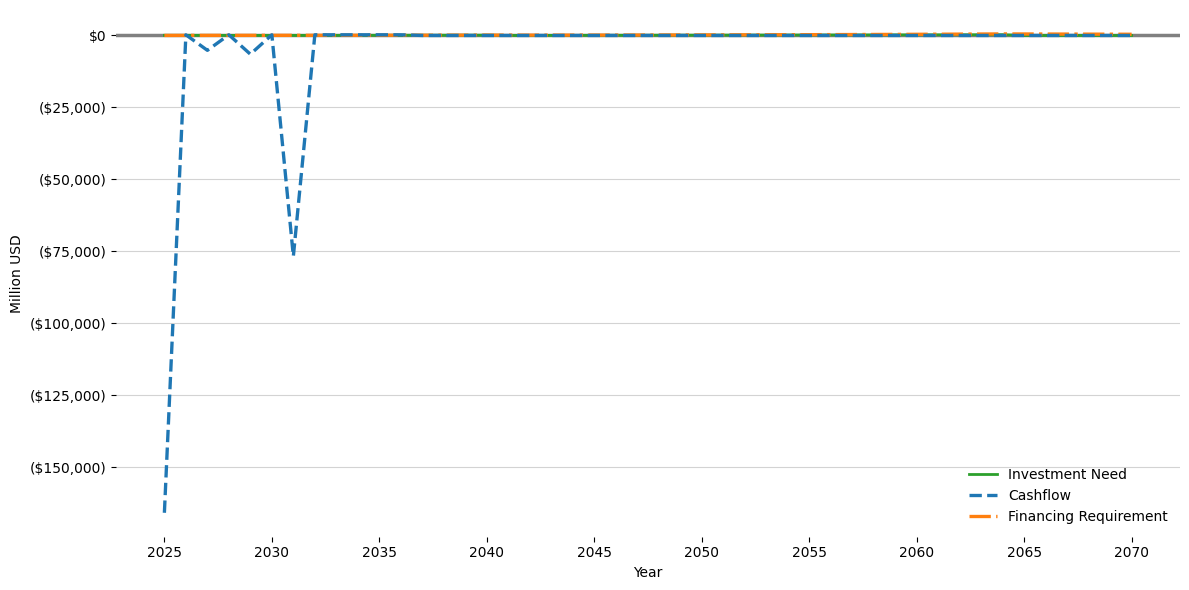

In [88]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from MinFin.plotting_notebook import fmt_million_usd

tech = "Biomass"
years = tech_dataframes[tech]["investment_need"].index

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
inv = tech_dataframes[tech]["investment_need"]
cf = tech_dataframes[tech]["cashflow"]
fr = financing_requirement_by_tech[tech].T["Financing Requirement"]
ax.plot(years, inv, color="#2ca02c", linestyle="-", linewidth=2.0, zorder=3, label="Investment Need")
ax.plot(years, cf, color="#1f77b4", linestyle="--", linewidth=2.4, zorder=5, label="Cashflow")
ax.plot(years, fr, color="#ff7f0e", linestyle="-.", linewidth=2.4, zorder=4, label="Financing Requirement")
ax.axhline(0, color="grey", linewidth=2.5, zorder=2)
ax.set_xlabel("Year")
ax.set_ylabel("Million USD")
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_million_usd))
ax.grid(axis="y", color="lightgray", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc="best", frameon=False)
plt.tight_layout()
plt.show()


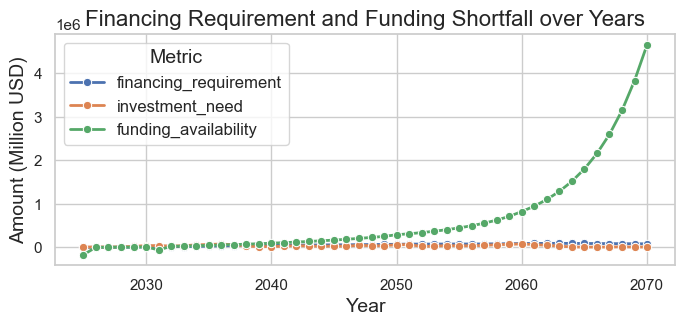

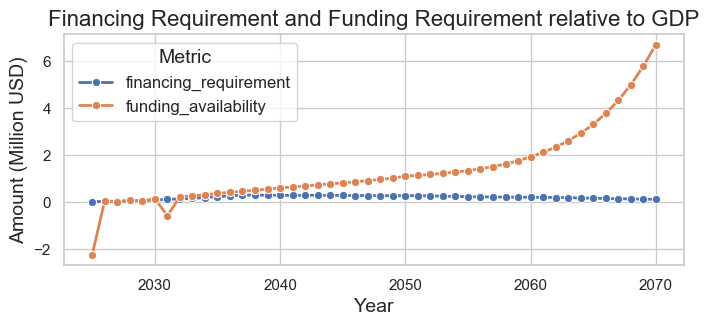

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from MinFin.plotting_notebook import plot_metric_time_series

plot_metric_time_series(
    dashboard_summary,
    selected_rows=["financing_requirement", "investment_need", "funding_availability"],
    title="Financing Requirement and Funding Shortfall over Years",
)
plot_metric_time_series(
    dashboard_summary / annual_gdp,
    selected_rows=["financing_requirement", "funding_availability"],
    title="Financing Requirement and Funding Requirement relative to GDP",
)


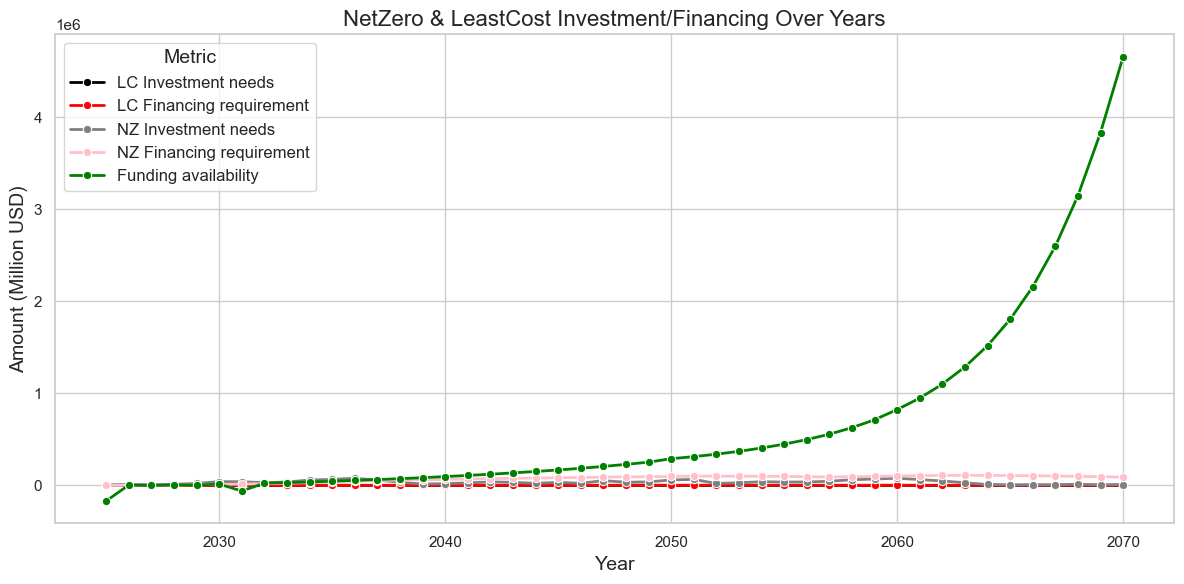

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume df_result structure is similar to:
#["NetZero Investment Needs (Million USD)", "NetZero Financing Requirements (Million USD)", ...]
# Columns: Years such as 2025, 2026, ...
# Each cell represents the value of the corresponding metric for that year

# 1. Select the 5 rows we need to plot, and transpose to make "Year" the row index
df_plot = pd.DataFrame({
                    "LC Investment needs": lc_needs.loc["Investment needs",:],
                    "LC Financing requirement": lc_needs.loc["Financing Requirements",:],
                    "NZ Investment needs": nz_needs.loc["Investment needs",:],
                    "NZ Financing requirement": nz_needs.loc["Financing Requirements",:],
                    "Funding availability": dashboard_summary.loc["funding_availability",:],
                })

# 2. Reset index and convert to long format for easier plotting with seaborn
df_plot = df_plot.reset_index().rename(columns={"index": "Year"})
df_long = df_plot.melt(id_vars="Year", var_name="Metric", value_name="Value")

# If Year is str, cast to int if needed
# df_long["Year"] = df_long["Year"].astype(int)

# 3. Seaborn style and plot
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Line colors (adjust as needed)
palette = {
    "LC Investment needs": "black",
    "LC Financing requirement": "red",
    "Funding availability": "green",
    "NZ Investment needs": "gray",
    "NZ Financing requirement": "pink",
}

ax = sns.lineplot(
    data=df_long,
    x="Year",
    y="Value",
    hue="Metric",
    palette=palette,
    marker="o",
    linewidth=2
)

# 4. Set title, axis labels, and legend
ax.set_title("NetZero & LeastCost Investment/Financing Over Years", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Amount (Million USD)", fontsize=14)
plt.legend(title="Metric", fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()



In [91]:
import pandas as pd
import plotly.express as px
from MinFin.plotting_notebook import plot_co2_emissions_scenarios

df_emissions = pd.DataFrame(
    {
        "Least Cost": least_cost_summary["co2_emission"],
        "Net Zero": net_zero_summary["co2_emission"],
        "Emissions Savings": -net_zero_summary["co2_emission"] + least_cost_summary["co2_emission"],
    },
    index=range(2025, 2070, 1),
)

plot_co2_emissions_scenarios(df_emissions)


In [92]:
df_funding_availability_full

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Government Budget,107.061333,143.073755,221.657001,278.5139,349.955076,439.721518,552.513813,694.238288,872.316292,1096.072812,...,521561.818072,655346.843854,823448.862375,1034670.473057,1300072.216661,1633551.756378,2052571.623767,2579073.637699,3240627.879513,4071876.390022
Liabilities Payments,314.810714,432.662002,346.622062,332.193141,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cashflows,-170238.768067,2416.330934,-3145.692495,2635.76019,-4434.60351,3049.704078,-76537.444072,3690.209611,4457.221801,5283.055911,...,18993.174788,19396.389073,19714.23688,19837.155509,20157.180412,20400.722317,20600.999857,20829.206231,21077.467361,-10499.901245
Capital Injection,33.333333,33.333333,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Carbon Credits,1520.1142,2322.7782,3576.8828,5511.5935,7939.5096,11586.7759,15776.5296,20509.0857,25635.945,31239.4016,...,408146.22,426119.109,444675.44,463837.346,483627.606,504069.736,525187.872,547940.565,571504.598,595919.909
Carbon Credit Price,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,...,3.8,3.9,4,4.1,4.2,4.3,4.4,4.5,4.6,4.7
Net CO2 Emissions Savings,7600.571,7742.594,8942.207,11023.187,13232.516,16552.537,19720.662,22787.873,25635.945,28399.456,...,107406.9,109261.31,111168.86,113131.06,115149.43,117225.52,119360.88,121764.57,124240.13,126791.47
CO2 Emissions Base Scenario,53419.259,54311.56,55795.776,57323.518,58908.37,60552.537,61720.662,62787.873,63635.945,64399.456,...,107406.9,109261.31,111168.86,113131.06,115149.43,117225.52,119360.88,121764.57,124240.13,126791.47
CO2 Emissions Net Zero Scenario,45818.688,46568.966,46853.569,46300.331,45675.854,44000,42000,40000,38000,36000,...,0,0,0,0,0,0,0,0,0,0
Total,-168893.069914,4482.854221,306.225245,8093.674449,3854.861166,15076.201495,-60208.400658,24893.533599,30965.483093,37618.530323,...,948701.21286,1100862.341928,1287838.539255,1518344.974566,1803857.003074,2158022.214695,2598360.495624,3147843.40893,3833209.944874,4657296.397777


In [93]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
from MinFin.plotting_notebook import stacked_area_fig, DEFAULT_STACK_COLOR_MAP as color_map

width = 800
height = 600
years = list(dashboard_summary.columns)

df_funding_plot = pd.DataFrame(
    {
        "Year": dashboard_summary.columns,
        "Government Budget": list(df_funding_availability_full.loc["Government Budget", years]),
        "Cashflows": list(df_funding_availability_full.loc["Cashflows", years]),
        "Capital injection": list(df_funding_availability_full.loc["Capital Injection", years]),
        "Carbon Credits": list(df_funding_availability_full.loc["Carbon Credits", years]),
        "Financing Requirement": dashboard_summary.loc["financing_requirement", years],
        "Funding Availability": dashboard_summary.loc["funding_availability", years],
    }
)

stacked_cols_funding = [
    "Government Budget",
    "Cashflows",
    "Capital injection",
    "Carbon Credits",
]
title = "Funding Availability"
fig = stacked_area_fig(
    df_funding_plot,
    stacked_cols_funding,
    width=800,
    height=600,
    color_map=color_map,
    title=title,
    line_plots=True,
)
fig.show()


In [94]:
import pandas as pd
import plotly.offline as pyo
from MinFin.plotting_notebook import plot_funding_shortfall_bar_interactive

pyo.init_notebook_mode(connected=True)
plot_funding_shortfall_bar_interactive(dashboard_summary, row_label="funding_shortfall")


In [95]:
# incremental_investment
net_zero_summary.head()
# df_5yr_avg["delta_capital_cost"].values
# df_financing_needs_ffr
# df_category_sum_nz
incremental_investment=df_category_sum_incremental
incremental_investment.columns


Index(['Distribution Infrastructure', 'Exports', 'Generation Fossil-Fuel',
       'Generation Renewable', 'Transmission Infrastructure', 'Biomass', 'CSP',
       'Coal', 'Direct Hydro', 'Direct Oil', 'Direct Solar', 'Distribution',
       'Energy Exports', 'Gas', 'Geothermal', 'Hydropower', 'Imports',
       'Nuclear', 'Oil', 'Solar PV', 'Transmission', 'Wind'],
      dtype='object')

In [96]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

width = 800
height = 600
df_long_nz = df_category_sum_nz.reset_index().melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)
df_long_incremental = incremental_investment.reset_index().melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)

# ==========  2 rows × 4 columns  ==========
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[
        "Plot 1: Investment Needs",       # Subplot 1 title
        "Plot 2: Cost of Capital",        # Subplot 2 title
        "Plot 3: Borrowed Sources",       # Subplot 3 title
        "Plot 4: Scenario Difference",    # Subplot 4 title
        "Plot 5: Future Needs by Source", # Subplot 5 title
        "Plot 6: Funding Shortfall",      # Subplot 6 title
        "Plot 7: Additional Metrics",     # Subplot 7 title
        "Plot 8: Another Metric"          # Subplot 8 title
    ]
)

color_map = {

    "Biomass": "#ff9900",       # Orange
    "Geothermal": "#66ccff",    # Light Blue
    "Solar PV": "#ffd700",      # Gold
    "Wind": "#66ff66",          # Light Green

    "Nuclear": "#999999",       # Gray
    
    "Hydropower": "#3399FF",    # Blue
    "CSP": "#FFB84D",           # Light Orange
    "Oil": "#808080",  # Medium Gray
    "Direct Oil": "#9966FF",  # Purple
    "Other": "#BEBEBE"          # Silver Gray
}

df_long_nz['Year'] = df_long_nz['Year'].astype(int).astype(str)

fig_area1 = px.area(
    df_long_nz, 
    x="Year", 
    y="InvestmentNeed", 
    color="Technology", 
    color_discrete_map=color_map,
    title="Projected Investment Needs to Reach Net Zero by 2050",
    labels={"InvestmentNeed": "Million US$", "Year": "Year"}
)
fig_area1.update_layout(
    template="plotly_white",
    showlegend=True,
    width=width,
    height=height
    )

fig_area2  = px.bar(
    df_long_incremental, 
    x="Year",
    y="InvestmentNeed",
    color="Technology",
    orientation="v",
    color_discrete_map=color_map,
    barmode="relative", 
    title="Additional Capital Cost of Net Zero",
    labels={"InvestmentNeed": "Million US$", "Year": "Year"}
)

fig_area2.update_layout(
    template="plotly_white",
    xaxis=dict(range=[2024.5, 2070.5]),
    yaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor="black"),
    width=width,
    height=height
)
fig_area2.update_layout(
    template="plotly_white",    
    )


df_cost = pd.DataFrame({
    "Scenario": ["NetZero", "NetZero", "NetZero"],
    "Cost Type": ["Capital Cost", "O&M Costs (Variable)", "O&M Costs (Fixed)"],
    "Value": [
        net_zero_summary["capital_cost"].sum(),
        net_zero_summary["variable_cost"].sum(),
        net_zero_summary["fixed_cost"].sum()
        ]  # Million US$
    })

fig_area3 = px.bar(
    df_cost,
    x="Scenario",
    y="Value",
    color="Cost Type",
    barmode="stack",  
    title="Total Undiscounted Scenario Cost 2025 to 2070",
    labels={"Value": "Million US$", "Scenario": ""}
)

fig_area3.update_layout(
    template="plotly_white",
    bargap=0, 
    showlegend=True,
    width=width,
    height=height
    )

df_diff = pd.DataFrame({
    "Year": df_5yr_avg["Year"],
    "Capital Cost":  list(df_5yr_avg["delta_capital_cost"].values),
    "Variable Cost": list(df_5yr_avg["delta_variable_cost"].values),
    "Fixed Cost":    list(df_5yr_avg["delta_fixed_cost"].values),
    "Cost of Carbon":list(df_5yr_avg["emission_saving"].values),
    # "Net Benefits":  df_5yr_avg["delta_capital_cost"]
})
# df_diff = pd.DataFrame({
#     "Year": df_5yr_avg["Year"],
#     "Capital Cost": list(df_5yr_avg["delta_capital_cost"].values),
#     "Variable Cost": [0,   20, 8,   0,   30,  0,   0,   0,   0  ],
#     "Fixed Cost":    [0,   0,  7,   0,   0,   0,   0,   0,   0  ],
#     "Cost of Carbon":[0,   0,  0,   30,  37,  40,  50,  60,  70 ],
#     "Net Benefits":  [-46, 20, 15, 47,  67, 107, 221, 275, 370]
# })
df_diff_long= df_diff.melt(
    id_vars=["Year"],  
    value_vars=["Capital Cost", "Variable Cost", "Fixed Cost", "Cost of Carbon"],
    var_name="Cost Type",
    value_name="Value"
)
df_diff["Net Benefits"] = df_diff["Capital Cost"] + df_diff["Variable Cost"] + df_diff["Fixed Cost"] + df_diff["Cost of Carbon"]

color_map_costs = {

    "Cost of Carbon": "#66ff66",          # Light Green

    "Variable Cost": "#cc6600",           # Dark Orange

    "Capital Cost": "#3399FF",    # Blue
    "Fixed Cost":    "#66ccff"   # Light Blue
}
# stacked bar chart
fig_area4 = px.bar(
    df_diff_long,
    x="Year",
    y="Value",
    color="Cost Type",
    color_discrete_map=color_map_costs,
    barmode="relative",  
    title="Differential benefits and costs of NZ vs BAU (Million US$)",
    labels={"Value": "Million US$", "Year": "Year"}
)
fig_area4.add_trace(
    go.Scatter(
        x=df_diff["Year"],           
        y=df_diff["Net Benefits"],   # Net Benefits
        mode="markers+text",    
        text=df_diff["Net Benefits"].apply(lambda x: f"{round(x)}").astype(str),  
        textposition="top center",            
        marker=dict(
            symbol=141,       # horizontal line symbol 'line-ew', 141, '141'
            size=20,                # the length of the line is determined by size
            color="red",
        ),
        name="Net Benefits"     
    )
)
fig_area4.update_layout(
    template="plotly_white",
    showlegend=True,
    xaxis=dict(range=[2020.5, 2070.5]),
    width=width,
    height=height
    )


# 1) data 
df_stranded_cost = pd.DataFrame({
    "Fuel": ["Coal", "Gas", "Oil"],
    "Extra Stranded Cost": [0, 0, 0]  # initialised with 0, will be updated later
})
since_year = 2025
for tech in  df_stranded_cost["Fuel"]:
    # Calculate cumulative stranded costs from since_year
    df_stranded_cost.loc[df_stranded_cost["Fuel"]==tech, "Extra Stranded Cost"]=df_financing_needs_ffr.loc[df_financing_needs_ffr.index >= since_year,(tech,tech)].sum()
# 2) Draw a bar chart
fig_stranded_cost = px.bar(
    df_stranded_cost,
    x="Fuel",
    y="Extra Stranded Cost",
    title="Extra Stranded Cost Compensation of Net Zero",
    labels={"Extra Stranded Cost": "Million US$", "Fuel": ""},
    text="Extra Stranded Cost"  # show values on the bar
)

    
df_plot = pd.DataFrame({
    "Year": df_category_sum_nz.reset_index()["Year"],
    "Net Zero Financing Needs": df_category_sum_nz.copy().reset_index().sum(axis=1),
})
# Convert both columns to the same data type (float)
df_plot["Net Zero Financing Needs"] = df_plot["Net Zero Financing Needs"].astype(float)

fig_needs_by_source = px.bar(
    df_plot,
    x="Year",
    y=["Net Zero Financing Needs"],
    barmode="relative",
    color_discrete_sequence=["grey", "black"],
    title="Future Investment Needs by Source",
    labels={"value": "Million US$", "variable": ""},  # adjust the legend/axis labels
    template="plotly_white",
)

# add black border to all bars
fig_needs_by_source.update_traces(marker=dict(line=dict(color="black", width=1)))

# adjust layout, e.g. move the legend below, change the width and height
fig_needs_by_source.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.15,  # legend below
        xanchor="center",
        x=0.5
    ),
    xaxis=dict(range=[2024, 2070.5]),
    
    width=width,
    height=height
)

df = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["cost_of_elec"],
    "LeastCost": least_cost_summary["cost_of_elec"],
})

# melt NetZero and LeastCost into "Scenario" and "Cost" two columns
df_long_elec_cost = df.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)
# now the structure of df_long is similar to:
#   Year   Scenario   Cost
# 0 2025   NetZero    14
# 1 2030   NetZero    15
# 2 2035   NetZero    12
# ... 
# . 2025   LeastCost  14

fig_elec_cost = px.line(
    df_long_elec_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Average Cost of Electricity US$/TWh",
    labels={"Cost": "US$/TWh", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  # customise colors
)

fig_elec_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # according to your data range, or let Plotly decide
    width=width,
    height=height
)


df_capital = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["capital_cost"],
    "LeastCost": least_cost_summary["capital_cost"],
})

# melt NetZero and LeastCost into "Scenario" and "Cost" two columns
df_capital_cost = df_capital.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)

fig_capital_cost = px.line(
    df_capital_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Capital Cost NZ vs LC",
    labels={"Cost": "Million US$", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  
)

fig_capital_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # according to your data range, or let Plotly decide
    width=width,
    height=height
)


fig.update_layout(template="plotly_white")
# fig_area1.show()
fig_area2.show()
# fig_area3.show()
# fig_area4.show()
# fig_stranded_cost.show()
# fig_needs_by_source.show()
# fig_elec_cost.show()
# fig_capital_cost.show()
# df_long_nz.head(300)


### Here we save the figures 
- In both HTML and .png

### Example usage for the functions:
>
```python
# Import the figure saving utilities
from save_figure import save_figure, save_all_figures

# Basic usage - single line per figure
save_figure(fig_area1)  # Uses figure title as filename
save_figure(fig_area2, custom_name="investment_by_tech") 
save_figure(fig_area3, save_png=False)  # HTML only

# Save to a different directory
save_figure(fig_elec_cost, output_dir="important_figures")

# Save all figures at once
figs = {"area1": fig_area1, "area2": fig_area2, "needs": fig_needs_by_source}
save_all_figures(figs)  # Uses dict keys as filenames

#or 
figs = [fig_area1, fig_area2, fig_needs_by_source]
save_all_figures(figs)  # Uses figure titles as filenames
```

In [97]:
# Create figures directory if it doesn't exist
import os
# os.makedirs("figures", exist_ok=True)
from MinFin.save_figure import save_figure, save_all_figures

# Save all figures at once (as a list)
all_figures = [fig_area1, fig_area2, fig_area3, fig_area4, 
               fig_stranded_cost, fig_needs_by_source, 
               fig_elec_cost, fig_capital_cost]
save_all_figures(all_figures)


Saved HTML: minfin_output/figures\Projected_Investment_Needs_to_Reach_Net_Zero_by_2050.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Additional_Capital_Cost_of_Net_Zero.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Total_Undiscounted_Scenario_Cost_2025_to_2070.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Differential_benefits_and_costs_of_NZ_vs_BAU_(Million_US$).html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Extr

### Funding Availability Projections

This section analyzes historical and projected funding sources for energy investments:

1. **Data Preparation**:
   - Extracts yearly funding data from `df_funding_envelope`
   - Creates a structured DataFrame with three key funding sources

2. **Visualization**:
   - Creates a bar chart showing historical funding sources by year
   - Generates a stacked area chart displaying future funding projections
   - Uses custom colors to differentiate between funding sources

3. **Output**:
   - Both visualizations help identify funding trends and potential gaps
   - Automatically saves figures to the `figures` directory for later use

The `save_all_figures()` function at the end preserves both visualizations as interactive HTML and static PNG files.

In [98]:
import plotly.express as px
year_idx = [x for x in df_funding_envelope.index
 if isinstance(x, (int, float))]
df_funding_historic_plot = df_funding_envelope.loc[year_idx]

df_funding = pd.DataFrame({
    "Year": year_idx,  
    "Government Spending": list(df_funding_historic_plot["Budget"]),
    "SOE internal cash generation":  list(df_funding_historic_plot["SOE Gen."]),
    "International Grants":  list(df_funding_historic_plot["Grant"])
})
fig = px.bar(
    df_funding,
    x="Year",
    y=["Government Spending", "SOE internal cash generation", "International Grants"],
    barmode="relative",  
    title="Historic Sources of Funding Availability for Energy Investments",
    labels={"value": "Million US$", "variable": ""},  
    template="plotly_white",
    color_discrete_sequence=["#fcfab2","#c4b97a", "#d7ea64" ]
)

fig.update_layout(
    xaxis=dict(dtick=1),  
    yaxis=dict(range=[0, 800]),  
    width=width,
    height=height,
    legend=dict(
    orientation="h",   
    yanchor="bottom",
    y=-0.2,            
    xanchor="center",
    x=0.5             
    )
)

fig.show()
fig_funding_projection = stacked_area_fig(df_funding_plot, stacked_cols_funding,width=800,height=600,color_map=color_map,title=title,line_plots=0)
fig_funding_projection.show()
save_all_figures([fig,fig_funding_projection])

Saved HTML: minfin_output/figures\Historic_Sources_of_Funding_Availability_for_Energy_Investments.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Funding_Availability.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Historic Financing (2010-2024)
This section analyzes the composition of historical energy investment financing from 2010-2024, breaking down funding sources across multiple dimensions:

1 Organization:
> Provider: Public vs. Private sector contributions
> 
> Instrument: Debt vs. Equity financing proportions
> 
> Origin: Domestic vs. International funding sources
> 
> Source: Detailed breakdown by specific financing entities

2 Data:
> Extracts relevant data from financing datasets
> 
> Combines different categories into a unified structure
> 
> Converts wide-format data to long-format for visualization

In [99]:
institution_shares #= fbs.get_institution_shares()
financing_sector_shares #= fbs.get_financing_sector_shares()
# repayment_statistics
hd.get_financing_source_shares()

,Historical,Projected
Conc_IFI,0.419847,0.419847
Conc_DPS,0.111346,0.111346
Comm_Intl,0.414019,0.414019
Comm_Dom,0.054789,0.054789


In [100]:
df_provider = financing_sector_shares.loc[["Public", "Private"],:].T
df_instrument = repayment_statistics.loc[("Summary","Total financing volumes"),["Debt Share", "Equity Share"]].T
df_source =hd.get_financing_source_shares().loc[:,"Historical"].to_frame().T
df_source

,Conc_IFI,Conc_DPS,Comm_Intl,Comm_Dom
Historical,0.419847,0.111346,0.414019,0.054789


In the following cell we:

- Build horizontal stacked bar charts for percentage distributions.
- Plot each financing dimension as its own category.
- Use custom colors for subcategories.


In [101]:
import pandas as pd

df_provider = financing_sector_shares.loc[["Public", "Private"],:].T
df_instrument = repayment_statistics.loc[("Summary","Total financing volumes"),["Debt Share", "Equity Share"]].to_frame().T
df_origin = financing_sector_shares.loc[["Domestic", "International"],:].T
df_source = hd.get_financing_source_shares().loc[:,"Historical"].to_frame().T

df_provider["Category"] = "Provider"
df_instrument["Category"] = "Instrument"
df_origin["Category"] = "Origin"
df_source["Category"] = "Source"

# Merge 4 dataframes
df_wide = pd.concat([df_provider, df_instrument, df_origin, df_source], ignore_index=True)

df_long = df_wide.melt(
    id_vars="Category",
    var_name="Subcategory",
    value_name="Value"
)

# If some rows have NaN (e.g. because they don't exist in the original data), discard them
df_long = df_long.dropna(subset=["Value"]).reset_index(drop=True)

import plotly.express as px
# color_map = {
#     "Conc IFI": "#99CCFF",
#     "Conc DPS": "#FFCC99",
#     "Comm Intl": "#FF9999",
#     "Comm Dom": "#FFFF99",
#     "Domestic": "#FFCC66",
#     "International": "#66CC99",
#     "Debt": "#99FF99",
#     "Equity": "#66CC66",
#     "Public": "#CCCCFF",
#     "Private": "#CC99FF"
# }

fig = px.bar(
    df_long,
    x="Value",
    y="Category",
    color="Subcategory",
    text="Subcategory",
    orientation="h",
    barmode="relative",  # stack
    color_discrete_map=color_map,
    title="Historic Sources of Finance for Energy Investments 2010-2024",
    labels={"Value": "Percentage (%)", "Category": ""}
)
fig.update_traces(
    # ,      
    textposition="inside",    # put text inside the bar
    insidetextanchor="middle" # center the text vertically
)

fig.update_xaxes(range=[0, 1])

fig.update_layout(
    template="plotly_white",
    showlegend = False,
    width = width,
    height = height,
    # margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()
save_figure(fig)

Saved HTML: minfin_output/figures\Historic_Sources_of_Finance_for_Energy_Investments_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



{'html': 'minfin_output/figures\\Historic_Sources_of_Finance_for_Energy_Investments_2010-2024.html'}

In [102]:
repayment_statistics

Volume (USD) Interest rate       Term  \
Summary Total financing volumes   5181.69874       0.09848  20.607191   
        Conc_IFI                  2175.51874      0.023848   22.55331   
        Conc_DPS                      576.96      0.043495  13.663512   
        Comm_Intl                    2145.32      0.173584  20.157509   
        Comm_Dom                       283.9      0.214591  23.203593   
Equity  Total financing volumes       1383.9      0.212864  21.014885   
        Conc_IFI                        90.0      0.071222       20.0   
        Conc_DPS                           0             0          0   
        Comm_Intl                     1010.0         0.225  20.490099   
        Comm_Dom                       283.9      0.214591  23.203593   
Debt    Total financing volumes   3797.79874      0.056799   20.45863   
        Conc_IFI                  2085.51874      0.021804  22.663498   
        Conc_DPS                      576.96      0.043495  13.663512   
        Comm_Intl                    1135.32      0.127843  19.861632   
        Comm_Dom                           0             0          0   

                                Grace period Average Annual Payment  \
Summary Total financing volumes     2.222273              37.440542   
        Conc_IFI                    4.614259                7.01444   
        Conc_DPS                     2.14596               32.50375   
        Comm_Intl                   0.111223              73.221803   
        Comm_Dom                         0.0              10.243041   
Equity  Total financing volumes          0.0              69.488365   
        Conc_IFI                         0.0               4.145167   
        Conc_DPS                           0                      0   
        Comm_Intl                        0.0              91.964242   
        Comm_Dom                         0.0              10.243041   
Debt    Total financing volumes     3.032059              25.762466   
        Conc_IFI                    4.813386               7.138263   
        Conc_DPS                     2.14596               32.50375   
        Comm_Intl                   0.210168              56.548211   
        Comm_Dom                           0                      0   

                                 Debt Share  Equity Share  Market Element  \
Summary Total financing volumes    0.732925      0.267075             NaN   
        Conc_IFI                   0.958631      0.041369             NaN   
        Conc_DPS                   1.000000      0.000000             NaN   
        Comm_Intl                  0.529208      0.470792             NaN   
        Comm_Dom                   0.000000      1.000000             NaN   
Equity  Total financing volumes         NaN           NaN             NaN   
        Conc_IFI                        NaN           NaN             NaN   
        Conc_DPS                        NaN           NaN             NaN   
        Comm_Intl                       NaN           NaN             NaN   
        Comm_Dom                        NaN           NaN             NaN   
Debt    Total financing volumes         NaN           NaN        0.226792   
        Conc_IFI                        NaN           NaN        0.180929   
        Conc_DPS                        NaN           NaN        0.428760   
        Comm_Intl                       NaN           NaN        0.208403   
        Comm_Dom                        NaN           NaN        0.000000   

                                 Grant Element  
Summary Total financing volumes            NaN  
        Conc_IFI                           NaN  
        Conc_DPS                           NaN  
        Comm_Intl                          NaN  
        Comm_Dom                           NaN  
Equity  Total financing volumes            NaN  
        Conc_IFI                           NaN  
        Conc_DPS                           NaN  
        Comm_Intl                          NaN  
   

In [103]:
import plotly.graph_objects as go
import pandas as pd
volume={"Conc_IFI": 0,
    "Conc_DPS":  0,
    "Comm_Intl":  0,
    "Comm_Dom":   0}
df_raw = pd.DataFrame({
    "MarketElement": list(repayment_statistics.loc[("Debt",list(volume.keys())),"Market Element"]),
    "volume": list(repayment_statistics.loc[("Debt",list(volume.keys())),"Volume (USD)"]),
    "color": ["#ffbbbc", "#ff7b7b", "#ff0000", "#c00000"]
},index=volume.keys())

df_sorted = df_raw.sort_values("MarketElement")
df_plot = df_sorted.copy()


base = df_raw.loc[:,"volume"].cumsum()-df_raw.loc[:,"volume"]

fig = go.Figure()

a = df_plot.loc[:,"volume"].cumsum()
for key, v in volume.items():
    y_val = df_plot.loc[key,"MarketElement"]
    x_val = df_plot.loc[key,"volume"]#+base[key]
    # print([y_val])
    fig.add_trace(
        go.Bar(
            x=[x_val],         
            y=[y_val],
            base= base[key],
            orientation="h",
            marker_color=df_plot.loc[key,"color"],
            name=key,
            width=y_val,              
            offset=-y_val              # offset 0.15, align the down edge of the bar to y_val
        )
    )

fig.update_layout(
    title="Merit order of Financing Sources by Grant Element between 2010-2024",
    showlegend=True,
    barmode="relative",   
    xaxis=dict(title="Amount ($)", range=[0, 9000]),
    yaxis=dict(title="Market Element", range=[0,1], zeroline=True),
    template="plotly_white",
    width=width,
    height=height
)
save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Merit_order_of_Financing_Sources_by_Grant_Element_between_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



>Potential issue of the above fig

In [104]:
df_plot

,MarketElement,volume,color
Comm_Dom,0.000000,0.00000,#c00000
Conc_IFI,0.180929,2085.51874,#ffbbbc
Comm_Intl,0.208403,1135.32000,#ff0000
Conc_DPS,0.428760,576.96000,#ff7b7b


### Financial Institution Contributions Analysis (2010-2024)

This section visualizes the proportional contributions from different financial institutions to energy investments during 2010-2024:

1. **Data Preparation**:
   - Organizes institution contribution data into plotting format
   - Adds empty placeholder column for proper horizontal display

2. **Custom Visualization Function**:
   - Implements a reusable `single_bar_plot()` function for horizontal stacked bars
   - Handles percentage formatting when values are between 0-1
   - Positions the legend horizontally at the bottom for better readability

3. **Output**:
   - Displays the relative contribution of each financial institution
   - Shows the historic proportion of funding from each source
   - Helps identify the most significant financial contributors

The visualization provides insights into which institutions have historically played the largest roles in financing energy investments.

In [105]:
import plotly.express as px
from MinFin.save_figure import save_figure
from MinFin.plotting_notebook import single_bar_plot

color_map = {
    "Bilateral Agency": "#7f6000",
    "Multilateral Agency": "#bf9000",
    "Foreign Government": "#ffc000",
    "National Government": "#ffd966",
    "Domestic Public Sector": "#ffe699",
    "Climate Funds": "#fff2cc",
    "Commercial Bank": "#2f5597",
    "Private Equity Fund": "#4472c4",
}
df_institution_shares_plot = pd.DataFrame(
    {"Financier": institution_shares.index, "Share": institution_shares["Share"]}
)
df_institution_shares_plot[""] = ""

fig = single_bar_plot(
    df_institution_shares_plot,
    "Share",
    "",
    color_map,
    "Historic Proportion of Contributions from Financier 2010-2024",
    {"Share": "Percentage", "Row": ""},
)
save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Historic_Proportion_of_Contributions_from_Financier_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Historical Financing Sources Visualisation

This section analyzes the breakdown of financing by source type and financial instrument (debt vs. equity; Domestic vs. international):

1. **Data Extraction**:
   - Identifies four key financing source types: Concessional IFI, Concessional DPS, Commercial International, and Commercial Domestic
   - Extracts volume data for both debt and equity instruments across these sources
   - Combines source type and instrument into unified categories (e.g., "Conc_IFI (Debt)")

2. **Visualization Preparation**:
   - Creates a custom color scheme to distinguish between different financing sources
   - Calculates percentage shares for relative comparison
   - Prepares data for horizontal bar chart visualization

3. **Multiple Views**:
   - First chart shows the relative share (percentage) of each financing source-instrument combination
   - Second chart presents the absolute volumes in USD
   - Both visualizations use the same color scheme for consistency

In [106]:
repayment_statistics
types = ["Conc_IFI", "Conc_DPS", "Comm_Intl", "Comm_Dom"]
df_new = repayment_statistics.loc[(["Debt","Equity"],types),"Volume (USD)"]
# df_new = df_new.rename(columns={"value": "Amount"})

In [107]:
types = ["Conc_IFI", "Conc_DPS", "Comm_Intl", "Comm_Dom"]
df_source_share = repayment_statistics.loc[(["Debt","Equity"],types),"Volume (USD)"]

df_source_share = df_source_share.reset_index() # reset multi-level index to single level
#  ["level_0", "level_1", "value"]

df_source_share["merged"] = df_source_share["level_1"] + " (" + df_source_share["level_0"] + ")"

color_map_source_share = ["#7f6000", "#bf9000", "#ffc000","#ffd966","#ffe699","#fff2cc","#2f5597","#4472c4"]
color_map_source_share = {k:v for k,v in zip(df_source_share["merged"].unique(), color_map_source_share)}

df_source_share_plot = pd.DataFrame({
    "Financier": df_source_share["merged"],
    "Share": df_source_share["Volume (USD)"]/df_source_share["Volume (USD)"].sum()
})
df_source_share_plot[""] = ""
fig = single_bar_plot(df_source_share_plot, "Share", "", color_map_source_share, "Historic Proportion of Contributions from Different Sources 2010-2024", {"Share": "Percentage", "Row": ""})

save_figure(fig)
fig.show()

df_source_share_plot = pd.DataFrame({
    "Financier": df_source_share["merged"],
    "Share": df_source_share["Volume (USD)"]
})
df_source_share_plot[""] = ""
fig = single_bar_plot(df_source_share_plot, "Share", "", color_map_source_share,  "Historic Proportion of Contributions from Different Sources 2010-2024", {"Share": "Percentage", "Row": ""})

save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Historic_Proportion_of_Contributions_from_Different_Sources_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved HTML: minfin_output/figures\Historic_Proportion_of_Contributions_from_Different_Sources_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



In [108]:
institution_shares

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.297115,0.168279,0.993505,0.006495
Multilateral Agency,0.090665,0.110880,1.000000,0.000000
Foreign Government,0.002567,0.078539,1.000000,0.000000
National Government,0.111346,0.349317,1.000000,0.000000
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.000000,NaN,NaN,NaN
Commercial Bank,0.150179,0.390442,0.897196,0.102804
Private Equity Fund,0.348129,NaN,0.000000,1.000000


In [109]:
df_category_sum_nz.reset_index()

,Year,Distribution Infrastructure,Exports,Generation Fossil-Fuel,Generation Renewable,Transmission Infrastructure,Biomass,CSP,Coal,Direct Hydro,...,Energy Exports,Gas,Geothermal,Hydropower,Imports,Nuclear,Oil,Solar PV,Transmission,Wind
0,2025,447.12062,0,1993.33772,4058.520861,0,56,192,96,467.21633,...,0,0,447.12062,1068.69277,0.000001,0,948.66886,913.74557,0,0
1,2026,1631.421,913.74557,2141.18721,4900.593582,913.74557,46,212,106,474.33443,...,913.74557,108.49441,203.22078,547.19878,0.000002,0,963.3464,1252.04701,913.74557,913.74557
2,2027,2781.8555,338.30144,2336.925202,3740.279736,338.30144,36,0.106144,0.053072,481.6732,...,338.30144,379.91425,447.12062,801.76193,0.000002,0,978.47894,817.6582,338.30144,338.30144
3,2028,3932.29,479.35676,2000.16116,5442.055062,479.35676,26,24,12,489.23947,...,479.35676,0,453.61576,819.25095,0.000002,0,994.08058,1575.29606,479.35676,479.35676
4,2029,3932.29,1095.9393,2044.278688,14362.723838,1095.9393,16,47.893856,23.946928,497.04029,...,1095.9393,0,460.31225,837.28214,0.000002,0,1010.16588,5704.128,1095.9393,1095.9393
5,2030,3932.29,4608.1887,5857.897456,23079.510564,4608.1887,6,71.787712,35.893856,505.08294,...,4608.1887,0,467.21633,855.87228,0.000002,0,2911.0018,8282.6813,4608.1887,4608.1887
6,2031,3932.29,3674.4926,9077.809184,20391.54221,3674.4926,16,95.681568,47.840784,1455.5009,...,3674.4926,0,474.33443,1112.63871,0.000002,0,4514.9842,6781.447,3674.4926,3674.4926
7,2032,3932.29,3106.9544,1010.187712,19810.031846,3106.9544,26,119.575424,59.787712,2257.4921,...,3106.9544,0,481.6732,1132.39932,0.000002,0,475.2,6342.9687,3106.9544,3106.9544
8,2033,3932.29,3236.0143,1022.13464,26481.801152,3236.0143,36,143.469279,71.73464,237.6,...,3236.0143,0,489.23947,1152.7725,0.000002,0,475.2,10593.3528,3236.0143,3236.0143
9,2034,3932.29,7357.3385,1034.081568,39492.829167,7357.3385,46,167.363135,83.681568,237.6,...,7357.3385,0,497.04029,1411.37724,0.000002,0,475.2,14888.055,7357.3385,7357.3385


### Market element visualisation


In [110]:
from MinFin.plotting_notebook import plot_market_element_by_financier
from MinFin.save_figure import save_figure

color_map = {
    "Bilateral Agency": "#7f6000",
    "Multilateral Agency": "#bf9000",
    "Foreign Government": "#ffc000",
    "National Government": "#ffd966",
    "Domestic Public Sector": "#ffe699",
    "Climate Funds": "#fff2cc",
    "Commercial Bank": "#2f5597",
    "Private Equity Fund": "#4472c4",
}

fig = plot_market_element_by_financier(
    institution_shares["Market Element"].to_frame(),
    color_map=color_map,
)
save_figure(fig)
fig


Saved HTML: minfin_output/figures\Market_Elements_of_Finance_for_Energy_Investments_2010-2024_by_Financier.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Techonlogy level financing stats 


In [111]:
fbs.get_technology_stats()

,IRR,Volume of Finance,Interest Rate,Debt Share,Equity Share,WACC
Technology,,,,,,
Hydropower,0.000000,560.45000,0.020120,1.000000,0.000000,0.020120
Gas,0.212643,4069.62000,0.034300,0.561654,0.438346,0.112476
Distribution,0.000000,109.87000,0.005600,1.000000,0.000000,0.005600
Solar PV,0.175750,182.45874,0.040586,0.671159,0.328841,0.085033
Transmission,0.000000,59.30000,0.006667,1.000000,0.000000,0.006667
Oil,0.225000,200.00000,0.061067,0.750000,0.250000,0.102050


In [112]:
import pandas as pd
import plotly.express as px

# get the technology stats, use the function from fbs(financing baseline stats)

df_technology_financing = fbs.get_technology_stats()
df_technology_financing["Technology"] = df_technology_financing.index

# convert the data to long format(melt)
df_melted = df_technology_financing.melt(id_vars=["Technology"], value_vars=["IRR", "Interest Rate", "WACC"],
                     var_name="Metric", value_name="Value")

color_map = {"IRR": "#00ffcc", "Interest Rate": "#ffc000", "WACC": "#ff99ff"}    

fig = px.bar(
    df_melted,
    x="Technology",
    y="Value",
    color="Metric",
    title="Historic Cost of Financing 2010-2024",
    barmode="group",
    color_discrete_map=color_map,
    labels={"Value": "Percentage", "Technology": "Technology"},
    
)
fig.update_traces(marker=dict(line=dict(color='black', width=2)))

# adjust the Y axis to be percentage format
fig.update_layout(
    yaxis_tickformat=".0%",
    width=width,
    height=height,
    )

save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Historic_Cost_of_Financing_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Debt Equity financing stats for energy investments


In [113]:
#get data required for the plot
terms_debt_finance = repayment_statistics.loc["Debt",:]
terms_debt_finance
# Weighted average not used in EXCEL

,Volume (USD),Interest rate,Term,Grace period,Average Annual Payment,Debt Share,Equity Share,Market Element,Grant Element
Total financing volumes,3797.79874,0.056799,20.45863,3.032059,25.762466,NaN,NaN,0.226792,0.773208
Conc_IFI,2085.51874,0.021804,22.663498,4.813386,7.138263,NaN,NaN,0.180929,0.819071
Conc_DPS,576.96,0.043495,13.663512,2.14596,32.50375,NaN,NaN,0.428760,0.571240
Comm_Intl,1135.32,0.127843,19.861632,0.210168,56.548211,NaN,NaN,0.208403,0.791597
Comm_Dom,0,0,0,0,0,NaN,NaN,0.000000,1.000000


In [114]:
institution_shares

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.297115,0.168279,0.993505,0.006495
Multilateral Agency,0.090665,0.110880,1.000000,0.000000
Foreign Government,0.002567,0.078539,1.000000,0.000000
National Government,0.111346,0.349317,1.000000,0.000000
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.000000,NaN,NaN,NaN
Commercial Bank,0.150179,0.390442,0.897196,0.102804
Private Equity Fund,0.348129,NaN,0.000000,1.000000


- By Financier

In [115]:
import pandas as pd
from MinFin.plotting_notebook import debt_equity_plot
from MinFin.save_figure import save_figure

institution_shares.sort_values("Equity Share", inplace=True)
data = {
    "Financier": institution_shares.index,
    "Debt Share": institution_shares["Debt Share"],
    "Equity Share": institution_shares["Equity Share"],
}
df_debt_eq = pd.DataFrame(data)
fig = debt_equity_plot(df_debt_eq, "Debt Equity in Financing for Energy Investments 2010-2024 by Financier")
save_figure(fig)
fig


Saved HTML: minfin_output/figures\Debt_Equity_in_Financing_for_Energy_Investments_2010-2024_by_Financier.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- By Source


In [116]:
repayment_statistics.loc["Summary",["Debt Share","Equity Share"]]

,Debt Share,Equity Share
Total financing volumes,0.732925,0.267075
Conc_IFI,0.958631,0.041369
Conc_DPS,1.000000,0.000000
Comm_Intl,0.529208,0.470792
Comm_Dom,0.000000,1.000000


In [117]:
filtered_data = repayment_statistics.loc["Summary",["Debt Share","Equity Share"]].copy()
filtered_data.sort_values("Equity Share", inplace=True)
filtered_data = filtered_data.loc[filtered_data.index != "Total financing volumes",:]
data = {
    "Financier": filtered_data.index,
    "Debt Share": filtered_data["Debt Share"],
    "Equity Share": filtered_data["Equity Share"]
}
df = pd.DataFrame(data)    
fig=debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Source")
save_figure(fig)
fig


Saved HTML: minfin_output/figures\Debt_Equity_in_Financing_for_Energy_Investments_2010-2024_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- By Technology


In [118]:
technology_debt_equity_share = fbs.get_technology_stats()[["Debt Share", "Equity Share"]]
technology_debt_equity_share.sort_values("Equity Share", inplace=True)
data = {
    "Financier": technology_debt_equity_share.index,
    "Debt Share": technology_debt_equity_share["Debt Share"],
    "Equity Share": technology_debt_equity_share["Equity Share"]
}
df = pd.DataFrame(data)  
fig = debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Source")
save_figure(fig)
fig

Saved HTML: minfin_output/figures\Debt_Equity_in_Financing_for_Energy_Investments_2010-2024_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Future Financing Needs Projections

This section forecasts the projected financing requirements broken down by source type and instrument:

1. **Data Visualization**:
   - Presents a stacked area chart showing projected financing needs over time (2025-2050)
   - Categorizes financing by both source (IFI, DPS, International Commercial, Domestic Commercial) and instrument type (Debt vs. Equity)

2. **Financing Categories**:
   - **Conc IFI (Debt/Equity)**: Concessional financing from International Financial Institutions
   - **Conc DPS (Debt/Equity)**: Concessional financing from Domestic Public Sector
   - **Comm Intl (Debt/Equity)**: Commercial financing from International sources
   - **Comm Dom (Debt/Equity)**: Commercial financing from Domestic sources

3. **Trend Analysis**:
   - Illustrates how financing needs evolve over the projection period
   - Shows the changing composition of financing sources and instruments
   - Highlights periods of peak financing requirements

- Repayment projection 

In [119]:
years = list(nz_needs.columns)
df_stack_nz_needs = pd.DataFrame({
    "Year": years,
    "Conc IFI (Debt)": list(nz_needs.loc["Debt: Conc_IFI", years]),
    "Conc DPS (Debt)": list(nz_needs.loc["Debt: Conc_DPS", years]),
    "Comm Intl (Debt)": list(nz_needs.loc["Debt: Comm_Intl", years]),
    "Comm Dom (Debt)": list(nz_needs.loc["Debt: Comm_Dom", years]),
    "Conc IFI (Equity)": list(nz_needs.loc["Equity: Conc_IFI", years]),
    "Conc DPS (Equity)": list(nz_needs.loc["Equity: Conc_DPS", years]),
    "Comm Intl (Equity)": list(nz_needs.loc["Equity: Comm_Intl", years]),
    "Comm Dom (Equity)": list(nz_needs.loc["Equity: Comm_Dom", years])
})

stacked_cols=list(df_stack_nz_needs.columns[1:])
#["Debt: Conc_IFI", "Debt: Conc_DPS", "Debt: Comm_Intl", "Debt: Comm_Dom", 
#"Equity: Conc_IFI", "Equity: Conc_DPS", "Equity: Comm_Intl", "Equity: Comm_Dom"]

color_map = {
    "Conc IFI (Debt)": "#7f6000",
    "Conc DPS (Debt)": "#bf9000",
    "Comm Intl (Debt)": "#ffc000",
    "Comm Dom (Debt)": "#ffe699",
    "Conc IFI (Equity)": "#203864",
    "Conc DPS (Equity)": "#2f5597",
    "Comm Intl (Equity)": "#4472c4",
    "Comm Dom (Equity)": "#b4c7e7" 
}
colors = list(color_map.values())
color_map_nz_repay = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

f = stacked_area_fig(
    df_stack_nz_needs, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_nz_repay,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
save_figure(f)
f

Saved HTML: minfin_output/figures\Net_Zero_Financing_Repayment_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



In [120]:
nz_needs = hd.get_net_zero_financing_needs_full(df_invest_need_summary,df_funding_envelope) # Net Zero finacning needs
lc_needs = hd.get_least_cost_financing_needs_full(df_invest_need_summary,df_funding_envelope) # Least Cost finacning needs
additional_investment_needs = hd.get_additional_investment_needs(lc_needs,nz_needs) #Additional needs (NetZero - LeastCost)

needs_of_different_scenario = {"NetZero":nz_needs,"LeastCost":lc_needs,"Incremental":additional_investment_needs} #put them in one dict for further processing 


df_financing_repayments= hd.get_repayments(repayment_schedule,df_invest_need_summary,df_funding_envelope)
df_financing_repayments



,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Existing finance payments (Million USD),640.636093,633.789625,577.49773,573.638184,569.778637,565.91909,545.750794,536.382918,537.527646,494.99552,...,8.176898,3.975603,3.820809,3.666014,2.514469,0.0,0,0,0,0
Financing payments for construction of new energy,660.19473,1721.216264,2700.746389,4000.853413,6442.325356,10936.777109,15363.217169,18924.284631,23428.310813,30368.374369,...,106869.731845,109598.139442,110390.453408,109385.119138,107246.826125,105536.240389,102290.95648,99273.925055,95543.130653,90380.028802
Financing Payments for retirement of old fossil fuel technologies,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Capital Injection Repayment (Million USD),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [121]:

years = list(df_financing_repayments.columns)
df_stack_future_repayment = pd.DataFrame({
    "Year": years,
    "Existing finance payments": list(df_financing_repayments.loc["Existing finance payments (Million USD)", years]),
    "Construction of new energy": list(df_financing_repayments.loc["Financing payments for construction of new energy", years]),
})
stacked_cols=list(df_stack_future_repayment.columns[1:])

color_map = {
    "Financing Payments for retirement of old fossil fuel technologies": "#ff0003",
    "Existing finance payments": "#ff9999",
    "Financing payments for construction of new energy": "#a5a5a5",
}
colors = list(color_map.values())
color_map_future_repayment = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

fig_future_repayment = stacked_area_fig(
    df_stack_future_repayment, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_future_repayment,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
save_figure(fig_future_repayment)
fig_future_repayment

Saved HTML: minfin_output/figures\Net_Zero_Financing_Repayment_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



In [122]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# --- Parameters ---
YEAR_START, YEAR_END = 2025, 2050
years = list(range(YEAR_START, YEAR_END + 1))

# Annual funding availability (must match dashboard_summary after .T; row name may need adjusting)
fa = dashboard_summary.loc["funding_availability"].reindex(years).fillna(0)

# --- Financing requirement by technology and year ---
def _req_series(tech):
    s = financing_requirement_by_tech[tech].loc["Financing Requirement"]
    return s.reindex(years).fillna(0)

techs = list(financing_requirement_by_tech.keys())
req_df = pd.DataFrame({t: _req_series(t) for t in techs}).T  # rows=tech, cols=year

# --- Allocate total funding availability by share of yearly financing requirement ---
total_req_y = req_df.sum(axis=0)
with np.errstate(divide="ignore", invalid="ignore"):
    share = req_df.div(total_req_y.replace(0, np.nan), axis=1).fillna(0.0)
alloc_df = share.mul(fa, axis=1)

gap_df = req_df - alloc_df
gap_by_tech = gap_df.sum(axis=1).sort_values(ascending=False)

# --- Sanity check: sum of tech gaps per year should match dashboard funding_shortfall ---
check = gap_df.sum(axis=0)
ref = (
    dashboard_summary.loc["financing_requirement"].reindex(years).fillna(0)
    - fa
)
print("Max abs diff (per-year total vs funding_shortfall):", (check - ref).abs().max())

# --- Plot (plotly_white) ---
width, height = 800, 600

color_map = {
    "Biomass": "#ff9900",
    "Geothermal": "#66ccff",
    "Solar PV": "#ffd700",
    "Wind": "#66ff66",
    "Onshore Wind": "#66ff66",
    "Offshore Wind": "#66ff66",
    "Nuclear": "#999999",
    "Coal": "#333333",
    "Gas": "#ff6666",
    "Oil": "#cc6600",
    "Hydropower": "#3399FF",
    "CSP": "#FFB84D",
    "Distribution": "#808080",
    "Transmission": "#9966FF",
    "Battery": "#19d3f3",
    "Imports": "#2f5597",
    "Other": "#BEBEBE",
}
bar_colors = [color_map.get(t, "#888888") for t in gap_by_tech.index]

fig = go.Figure(
    go.Bar(
        x=gap_by_tech.index.astype(str),
        y=gap_by_tech.values,
        marker=dict(color=bar_colors, line=dict(color="black", width=1)),
        hovertemplate="%{x}<br>Gap (Million US$)=%{y:,.0f}<extra></extra>",
    )
)
fig.update_layout(
    title=f"Finance Gap by Technology ({YEAR_START}–{YEAR_END}) — requirement vs allocated funding",
    template="plotly_white",
    width=width,
    height=height,
    xaxis=dict(tickangle=-45, title="Technology"),
    yaxis=dict(title="Million US$", showgrid=True, gridcolor="lightgray", zeroline=True),
    showlegend=False,
)

try:
    from MinFin.save_figure import save_figure
    save_figure(fig, custom_name="Finance_Gap_by_Technology_requirement_vs_funding")
except Exception as e:
    print("save_figure:", e)

fig.show()


Max abs diff (per-year total vs funding_shortfall): 637.636093363486
Saved HTML: minfin_output/figures\Finance_Gap_by_Technology_requirement_vs_funding.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



In [123]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from MinFin.plotting_notebook import plot_technology_cashflow_waterfall
from MinFin.save_figure import save_figure

TECH = "Biomass"
YEAR = 2035

fig = plot_technology_cashflow_waterfall(
    TECH,
    YEAR,
    tech_dataframes,
    financing_requirement_by_tech,
    existing_financing_repayment=None,
)

try:
    save_figure(fig, custom_name=f"Technology_Cashflow_{TECH}_{YEAR}")
except Exception as e:
    print("save_figure:", e)

fig.show()


Saved HTML: minfin_output/figures\Technology_Cashflow_Biomass_2035.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



In [124]:
from MinFin.market_revenue import (
    aggregate_market_revenue_stacks,
    plot_net_zero_funding_sources_figure,
)

years = list(range(2025, 2051))

ppa, enduser, wholesale = aggregate_market_revenue_stacks(
    tech_dataframes,
    years,
    exchange_rates,
)

fr = dashboard_summary.loc["financing_requirement"].reindex(years).fillna(0)

fig = plot_net_zero_funding_sources_figure(
    years,
    ppa,
    enduser,
    wholesale,
    fr,
)
fig.show()
